In [32]:
import sys
import os
import subprocess

# 1. 시스템 레벨 확인 (NVIDIA 드라이버 및 WSL 인식 여부)
print("=== 1. System Level Check (nvidia-smi) ===")
try:
    nvidia_smi = subprocess.check_output(["nvidia-smi"]).decode("utf-8")
    print(nvidia_smi)
except Exception as e:
    print("Error: nvidia-smi command not found. Check if NVIDIA Driver is installed on Windows Host.")

# 2. PyTorch GPU 확인
print("\n=== 2. PyTorch GPU Check ===")
try:
    import torch
    cuda_available = torch.cuda.is_available()
    print(f"PyTorch Version: {torch.__version__}")
    print(f"CUDA Available: {cuda_available}")
    if cuda_available:
        print(f"Current GPU: {torch.cuda.get_device_name(0)}")
        print(f"GPU Count: {torch.cuda.device_count()}")
        # 실제 연산 테스트 (GPU로 텐서 이동)
        x = torch.tensor([1.0, 2.0]).cuda()
        print(f"Tensor Device: {x.device} (Success!)")
    else:
        print("Warning: PyTorch is installed but CUDA is not detected.")
except ImportError:
    print("PyTorch not installed.")

# 3. TensorFlow GPU 확인
print("\n=== 3. TensorFlow GPU Check ===")
try:
    import tensorflow as tf
    gpus = tf.config.list_physical_devices('GPU')
    print(f"TensorFlow Version: {tf.__version__}")
    print(f"GPUs Detected: {len(gpus)}")
    for i, gpu in enumerate(gpus):
        print(f" - GPU {i}: {gpu}")
    if len(gpus) > 0:
        # 실제 연산 테스트
        with tf.device('/GPU:0'):
            a = tf.constant([[1.0, 2.0]])
            print(f"TensorFlow Operation on GPU: Success!")
except ImportError:
    print("TensorFlow not installed.")

=== 1. System Level Check (nvidia-smi) ===
Fri Mar 13 09:50:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.45.03              Driver Version: 595.71         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4070 ...    On  |   00000000:01:00.0  On |                  N/A |
|  0%   49C    P2             31W /  220W |   11604MiB /  12282MiB |      1%      Default |
|                                         |                        |                  N/A |
+----

캐시 삭제: fontlist-v390.json


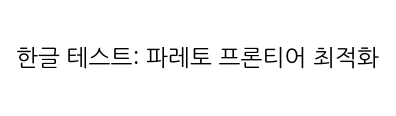

위에 한글이 정상 출력되면 성공


In [33]:
# == 한글 폰트 설정 (WSL/Linux 환경) ==
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib
import os
import glob

nanum_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

if not os.path.exists(nanum_path):
    print('나눔고딕 폰트 설치 중...')
    os.system('sudo apt-get install -y fonts-nanum > /dev/null 2>&1')

# matplotlib 폰트 캐시 강제 삭제
cache_dir = matplotlib.get_cachedir()
for f in glob.glob(os.path.join(cache_dir, '*.json')):
    os.remove(f)
    print(f'캐시 삭제: {os.path.basename(f)}')

# 폰트 매니저 재빌드 + 직접 등록
fm._load_fontmanager(try_read_cache=False)
fm.fontManager.addfont(nanum_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 확인
fig, ax = plt.subplots(figsize=(4, 1))
ax.text(0.5, 0.5, '한글 테스트: 파레토 프론티어 최적화', ha='center', va='center', fontsize=14)
ax.axis('off')
plt.show()
print('위에 한글이 정상 출력되면 성공')

In [110]:
# ====================================================================
# [Matplotlib 수식(Log 스케일 등) 마이너스 기호 깨짐 방지 패치]
# ====================================================================
import matplotlib.pyplot as plt

# 1. 일반 축의 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 2. 수식(MathText) 렌더링 폰트를 명시적으로 분리하여 지정
# 한글 폰트(NanumGothic)가 수식의 '-' 기호에 간섭하지 못하도록 방어합니다.
plt.rcParams['mathtext.fontset'] = 'dejavusans' 

print("✅ 마이너스 기호 및 수식 폰트 패치 완료! (이제 10^-1 이 정상 출력됩니다)")

✅ 마이너스 기호 및 수식 폰트 패치 완료! (이제 10^-1 이 정상 출력됩니다)


# [Step 1] 대리 모델(Surrogate)을 통한 데이터 증강 — v2 (Improved)

> **목표:** ~900개의 생존 시뮬레이션 데이터에서 300초 시계열의 **'절댓값 Max Peak(부호 유지)'**를 추출하고,  
> GPR(Gaussian Process Regression) 대리 모델을 학습하여 **10만 개의 가상 P1~P6 조합**에 대한 응력/변형 결과를 예측합니다.

### 핵심 물리 로직: '절댓값 Max Peak' 추출
열 사이클링에서 응력은 가열 시 (+), 냉각 시 (-) 방향으로 진동합니다.  
**단순 max()를 쓰면 냉각 시 압축 응력(음수)의 위험성을 놓칩니다.**  
따라서 `abs().idxmax()`로 절댓값이 가장 큰 시점을 찾되, 그 시점의 **원래 부호를 보존**합니다.

```python
# 절댓값이 가장 큰 시점의 인덱스 -> 해당 시점의 원본 값(부호 유지)
max_abs_idx = df_time[col].abs().idxmax()
peak_value  = df_time.loc[max_abs_idx, col]   # 예: -30 (압축 피크)
```

---
## 0. 환경 설정 및 라이브러리 로드

In [113]:
import os
import re
import glob
import time
import warnings
import platform
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, WhiteKernel
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.optimize import minimize as pymoo_minimize
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 9

# -- 디바이스 설정 (GPU 가용 시 자동 사용) --
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ====================================================================
# [경로 자동 설정] Windows와 WSL(Linux) 환경을 자동 감지하여 경로 할당
# ====================================================================
if platform.system() == 'Linux':
    CSV_FOLDER = '/mnt/i/ai_model_dev/cfd/SIM_CSV_DATA'
    MASTER_CSV = '/mnt/i/ai_model_dev/cfd/Master_DOE_1200.csv'
    BASE_DIR   = '/mnt/i/ai_model_dev/cfd'
else:
    CSV_FOLDER = r'I:\\ai_model_dev\\cfd\\SIM_CSV_DATA'
    MASTER_CSV = r'I:\\ai_model_dev\\cfd\\Master_DOE_1200.csv'
    BASE_DIR   = r'I:\\ai_model_dev\\cfd'

Y_COLUMNS = [
    'WarpMax',          # 패키지 전체 최대 열변형량 (최소화 메인 타겟 #1)
    'T_Tip_Peel',       # Top 계면 끝단 수직응력 - 박리 원인 (최소화 메인 타겟 #2)
    'T_Tip_Shear',      # Top 계면 끝단 전단응력 - 계면 피로 유발
    'T_Tip_SEQV',       # Top 끝단 Von Mises 등가응력 - 소성 변형 유발
    'T_Tip_Strain',     # Top 끝단 변형률
    'T_Avg_Peel',       # Top 접합면 평균 수직응력 - 중앙부 Void 유발
    'T_Avg_Shear',      # Top 접합면 평균 전단응력
    'B_Tip_Peel',       # Bottom 끝단 수직응력
    'B_Tip_Shear',      # Bottom 끝단 전단응력
    'B_Tip_SEQV',       # Bottom 끝단 Von Mises 등가응력
    'B_Tip_Strain',     # Bottom 끝단 변형률
    'B_Avg_Peel',       # Bottom 평균 수직응력
    'B_Avg_Shear',      # Bottom 평균 전단응력
    'Die_SX',           # 다이(실리콘 칩) 휨 응력 - Die Crack 유발
    'Die_SY_Max'        # 다이 최대 Y방향 응력 - 모서리 응력 집중
]

# 물리적으로 항상 양수(>=0)인 변수 목록 (외삽 시 음수 clipping 대상)
# Von Mises 등가응력과 변형률은 정의상 음수가 될 수 없음
POSITIVE_ONLY_COLS = ['T_Tip_SEQV', 'T_Tip_Strain', 'B_Tip_SEQV', 'B_Tip_Strain']

SEED = 42
np.random.seed(SEED)

print('=== 환경 설정 완료 (GPR 모드) ===')
print(f'현재 감지된 OS: {platform.system()}')
print(f'시계열 CSV 폴더 : {CSV_FOLDER}')
print(f'마스터 DOE 파일 : {MASTER_CSV}')
print(f'추출 대상 Y 변수: {len(Y_COLUMNS)}개')
print(f'양수 전용 변수  : {POSITIVE_ONLY_COLS}')

=== 환경 설정 완료 (GPR 모드) ===
현재 감지된 OS: Linux
시계열 CSV 폴더 : /mnt/i/ai_model_dev/cfd/SIM_CSV_DATA
마스터 DOE 파일 : /mnt/i/ai_model_dev/cfd/Master_DOE_1200.csv
추출 대상 Y 변수: 15개
양수 전용 변수  : ['T_Tip_SEQV', 'T_Tip_Strain', 'B_Tip_SEQV', 'B_Tip_Strain']


---
## 1. 마스터 DOE 로드 및 생존 CSV 탐지

**데이터 구조 (확인 완료):**
- `Master_DOE_1200.csv`: P1~P6 컬럼만 존재 (Row_ID 없음, 1200행)
  - 행 인덱스(0-based) + 1 = Row_ID로 매핑
  - P1: [0.80, 1.10] / P2: [0.05, 0.09] / P3: [0.60, 0.72]
  - P4: [0.10, 0.30] / P5: [1.20, 1.80] / P6: [0.04, 0.08]
- 시계열 파일: `ML_DATA_Extract_Row_{Row_ID}.csv` (617행 x 17열, 0.1~300초)

In [35]:
# == 1-1. 마스터 DOE 로드 ==
# P1~P6만 존재하는 1200행 파일. Row_ID 컬럼이 없으므로 직접 부여함.
df_master = pd.read_csv(MASTER_CSV)

# Row_ID 생성: 행 인덱스 + 1 = CSV 파일명의 Row 번호와 1:1 대응
# 즉, Master CSV의 1번째 행(index=0) -> Row_ID=1 -> ML_DATA_Extract_Row_1.csv
df_master.insert(0, 'Row_ID', range(1, len(df_master) + 1))

print(f'마스터 DOE 로드 완료: {len(df_master)}개 DP (Design Points)')
print(f'컬럼: {list(df_master.columns)}')
print()

# 각 P 변수의 범위 확인 (몬테카를로 생성 시 바운더리로 사용됨)
print('-- P1~P6 실제 범위 --')
for col in ['P1','P2','P3','P4','P5','P6']:
    print(f'  {col}: [{df_master[col].min():.4f}, {df_master[col].max():.4f}]')

display(df_master.head())

마스터 DOE 로드 완료: 1200개 DP (Design Points)
컬럼: ['Row_ID', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6']

-- P1~P6 실제 범위 --
  P1: [0.8005, 1.0998]
  P2: [0.0500, 0.0899]
  P3: [0.6001, 0.7198]
  P4: [0.1000, 0.2994]
  P5: [1.2003, 1.7997]
  P6: [0.0401, 0.0800]


,Row_ID,P1,P2,P3,P4,P5,P6
0,1,0.8317,0.0842,0.6021,0.1075,1.7454,0.0585
1,2,0.8143,0.0777,0.7136,0.1333,1.4174,0.0696
2,3,0.8013,0.0512,0.6363,0.2312,1.3751,0.0560
3,4,1.0509,0.0569,0.6031,0.2220,1.2660,0.0777
4,5,0.8744,0.0670,0.6206,0.2669,1.4158,0.0779


In [36]:
# == 1-2. 생존 CSV 파일 자동 탐지 ==
# 폴더를 스캔하여 실제 존재하는 시계열 파일의 Row_ID를 파싱
# (시뮬레이션이 터진 DP는 CSV 파일 자체가 생성되지 않음)

# glob으로 해당 폴더의 모든 ML_DATA_Extract_Row_*.csv 파일 탐색
pattern = os.path.join(CSV_FOLDER, 'ML_DATA_Extract_Row_*.csv')
found_files = sorted(glob.glob(pattern))

# 파일명에서 Row_ID 숫자를 정규식으로 추출
survived_ids = []
for fpath in found_files:
    fname = os.path.basename(fpath)
    match = re.search(r'Row_(\d+)\.csv', fname)
    if match:
        survived_ids.append(int(match.group(1)))

survived_ids = sorted(survived_ids)

# 전체 DP 수 = 폴더 내 가장 큰 Row_ID (실제 시뮬레이션이 시도된 총 수)
n_total = max(survived_ids)
n_alive = len(survived_ids)
n_dead  = n_total - n_alive

print(f'전체 DP      : {n_total}개 (최대 Row_ID 기준)')
print(f'생존 CSV     : {n_alive}개 ({n_alive/n_total*100:.1f}%)')
print(f'결측(터진) DP: {n_dead}개 ({n_dead/n_total*100:.1f}%)')
print(f'생존 Row_ID 범위: {min(survived_ids)} ~ {max(survived_ids)}')

전체 DP      : 1199개 (최대 Row_ID 기준)
생존 CSV     : 884개 (73.7%)
결측(터진) DP: 315개 (26.3%)
생존 Row_ID 범위: 1 ~ 1199


---
## 2. 시계열 데이터에서 '절댓값 Max Peak' 추출 (Feature Extraction)

각 생존 CSV(300초, 617 timestep)에서 15개 Y 채널별로:
1. `abs().idxmax()` -> 절댓값이 최대인 시간 인덱스 탐색
2. 해당 시점의 원본 값(부호 유지)을 피크로 기록

결과: **[Row_ID, P1~P6, Y1_peak ~ Y15_peak]** 형태의 정적 데이터셋 구축

In [37]:
# == 2-1. 생존 데이터 순회 및 Max Peak 추출 ==

valid_data = []     # 정상 추출된 데이터를 누적할 리스트
error_rows = []     # 읽기 오류가 발생한 Row_ID를 기록할 리스트

t_start = time.time()
print(f'{len(survived_ids)}개 생존 CSV에서 Max Peak 추출 시작...')

for i, row_id in enumerate(survived_ids):
    # 시계열 CSV 파일 경로 구성
    fpath = os.path.join(CSV_FOLDER, f'ML_DATA_Extract_Row_{row_id}.csv')
    
    try:
        # 시계열 데이터 로드 (617행 x 17열: Time, TempBase, 15 Y변수)
        df_ts = pd.read_csv(fpath)
        
        # 컬럼명 앞뒤 공백 제거 (CSV 헤더에 공백 포함될 수 있음)
        df_ts.columns = [c.strip() for c in df_ts.columns]
        
        # 마스터 DOE에서 해당 Row의 P1~P6 가져오기
        # Row_ID는 1-based이므로, df_master에서 Row_ID == row_id인 행을 찾음
        master_row = df_master[df_master['Row_ID'] == row_id]
        if master_row.empty:
            error_rows.append((row_id, 'Master DOE에 해당 Row_ID 없음'))
            continue
        
        # 결과 딕셔너리 초기화
        peak_dict = {'Row_ID': row_id}
        
        # P1~P6 설계변수 값 저장
        for p_col in ['P1','P2','P3','P4','P5','P6']:
            peak_dict[p_col] = master_row[p_col].values[0]
        
        # === 핵심 로직: 각 Y 채널별 '절댓값 최대 피크(부호 유지)' 추출 ===
        for y_col in Y_COLUMNS:
            if y_col in df_ts.columns:
                # Step A: 300초 시계열에서 절댓값이 가장 큰 시간 인덱스 탐색
                #   abs()로 절댓값을 취한 뒤 idxmax()로 최대 위치를 찾음
                max_abs_idx = df_ts[y_col].abs().idxmax()
                
                # Step B: 해당 시점의 원래 값(부호 보존)을 피크로 기록
                #   예) 시계열이 [+10, -30, +20]이면:
                #       abs = [10, 30, 20] -> idxmax = 1 -> 원본값 = -30
                #   이렇게 해야 냉각 시 압축 응력의 위험성을 놓치지 않음
                peak_dict[y_col] = df_ts.loc[max_abs_idx, y_col]
            else:
                # 해당 Y 컬럼이 CSV에 없는 경우 NaN 처리
                peak_dict[y_col] = np.nan
        
        valid_data.append(peak_dict)
        
    except Exception as e:
        error_rows.append((row_id, str(e)))
    
    # 진행률 표시 (200개마다)
    if (i + 1) % 200 == 0:
        print(f'  ... {i+1}/{len(survived_ids)} 처리 완료')

elapsed = time.time() - t_start

# 결과 취합
df_peaks = pd.DataFrame(valid_data)

print(f'\n=== Max Peak 추출 완료 ===')
print(f'성공: {len(df_peaks)}개 / 실패: {len(error_rows)}개 / 소요시간: {elapsed:.1f}초')

if error_rows:
    print(f'\n[경고] 오류 발생 Row (처음 5개): {error_rows[:5]}')

# NaN이 있는 행 확인 및 제거
nan_count = df_peaks[Y_COLUMNS].isnull().any(axis=1).sum()
if nan_count > 0:
    print(f'[경고] {nan_count}개 행에 NaN 존재 -> 해당 행 제거')
    df_peaks = df_peaks.dropna(subset=Y_COLUMNS).reset_index(drop=True)

print(f'\n최종 학습용 데이터: {len(df_peaks)}개')
display(df_peaks.head())

884개 생존 CSV에서 Max Peak 추출 시작...


  ... 200/884 처리 완료
  ... 400/884 처리 완료
  ... 600/884 처리 완료
  ... 800/884 처리 완료

=== Max Peak 추출 완료 ===
성공: 884개 / 실패: 0개 / 소요시간: 6.3초

최종 학습용 데이터: 884개


,Row_ID,P1,P2,P3,P4,P5,P6,WarpMax,T_Tip_Peel,T_Tip_Shear,...,T_Avg_Peel,T_Avg_Shear,B_Tip_Peel,B_Tip_Shear,B_Tip_SEQV,B_Tip_Strain,B_Avg_Peel,B_Avg_Shear,Die_SX,Die_SY_Max
0,1,0.8317,0.0842,0.6021,0.1075,1.7454,0.0585,-0.107084,-34.039048,-8.025589,...,0.023255,-3.071933,-5.445917,-2.957903,28.329506,0.002043,0.032548,-2.861042,66.203874,-85.012494
1,2,0.8143,0.0777,0.7136,0.1333,1.4174,0.0696,-0.144790,-31.629051,8.315480,...,0.031333,-2.707141,-4.092614,-2.676881,25.607135,0.001761,0.025406,-2.568996,63.021576,-87.551451
2,4,1.0509,0.0569,0.6031,0.2220,1.2660,0.0777,-0.158005,-38.879585,8.994357,...,0.084601,-2.668019,-4.944124,-2.822713,29.147154,0.001970,-0.027274,-2.938019,61.316208,-86.130069
3,5,0.8744,0.0670,0.6206,0.2669,1.4158,0.0779,-0.138039,-33.084874,8.631955,...,0.031446,-2.621313,-4.015564,-2.296843,26.291782,0.001684,-0.015385,-2.606656,58.891827,-81.062810
4,7,0.9347,0.0506,0.6789,0.1163,1.6356,0.0661,-0.120482,-41.494301,8.232958,...,0.081118,-2.695119,-5.653280,-2.729163,32.351288,0.002114,0.010124,-2.795657,58.882464,-89.189848


---
## 3. 탐색적 데이터 분석 (EDA)

학습 전 데이터의 분포와 상관관계를 시각화하여 이상 패턴을 사전 진단합니다.

In [38]:
# == 3-1. Y 변수 기술 통계 ==
print('=== Y 변수 기술 통계 (Max Peak 기준) ===')
display(df_peaks[Y_COLUMNS].describe().round(4))

=== Y 변수 기술 통계 (Max Peak 기준) ===


,WarpMax,T_Tip_Peel,T_Tip_Shear,T_Tip_SEQV,T_Tip_Strain,T_Avg_Peel,T_Avg_Shear,B_Tip_Peel,B_Tip_Shear,B_Tip_SEQV,B_Tip_Strain,B_Avg_Peel,B_Avg_Shear,Die_SX,Die_SY_Max
count,884.0000,884.0000,884.0000,884.0000,884.0000,884.0000,884.0000,884.0000,884.0000,884.0000,884.0000,884.0000,884.0000,884.0000,884.0000
mean,-0.1355,-35.4040,7.6981,38.0699,0.0035,0.0311,-2.8798,-5.9346,-2.7595,28.4034,0.0020,-0.0032,-2.8787,62.4292,-87.8805
std,0.0184,2.8803,4.2660,3.4596,0.0003,0.0307,0.3325,2.2284,0.4962,2.0138,0.0002,0.0200,0.3014,4.0792,5.6363
min,-0.1728,-47.2917,-13.0566,30.9377,0.0028,-0.0382,-5.2160,-12.5674,-6.0878,23.2101,0.0015,-0.0682,-5.2635,57.6809,-104.0513
25%,-0.1507,-37.2172,8.1783,35.6798,0.0033,0.0102,-2.9854,-7.1367,-3.0414,26.9401,0.0018,-0.0163,-2.9812,59.6579,-92.1257
50%,-0.1346,-35.2427,8.6427,37.6540,0.0035,0.0254,-2.7990,-5.8354,-2.7193,28.2902,0.0020,-0.0050,-2.8161,61.0581,-87.4272
75%,-0.1200,-33.3347,9.0892,39.8533,0.0037,0.0561,-2.6847,-4.8175,-2.4306,29.6110,0.0021,0.0130,-2.6850,64.2128,-83.7595
max,-0.0996,-28.7603,10.6679,56.8349,0.0049,0.1454,-2.3780,11.6636,-1.6034,38.1656,0.0031,0.0407,-2.3874,87.9883,-72.2885


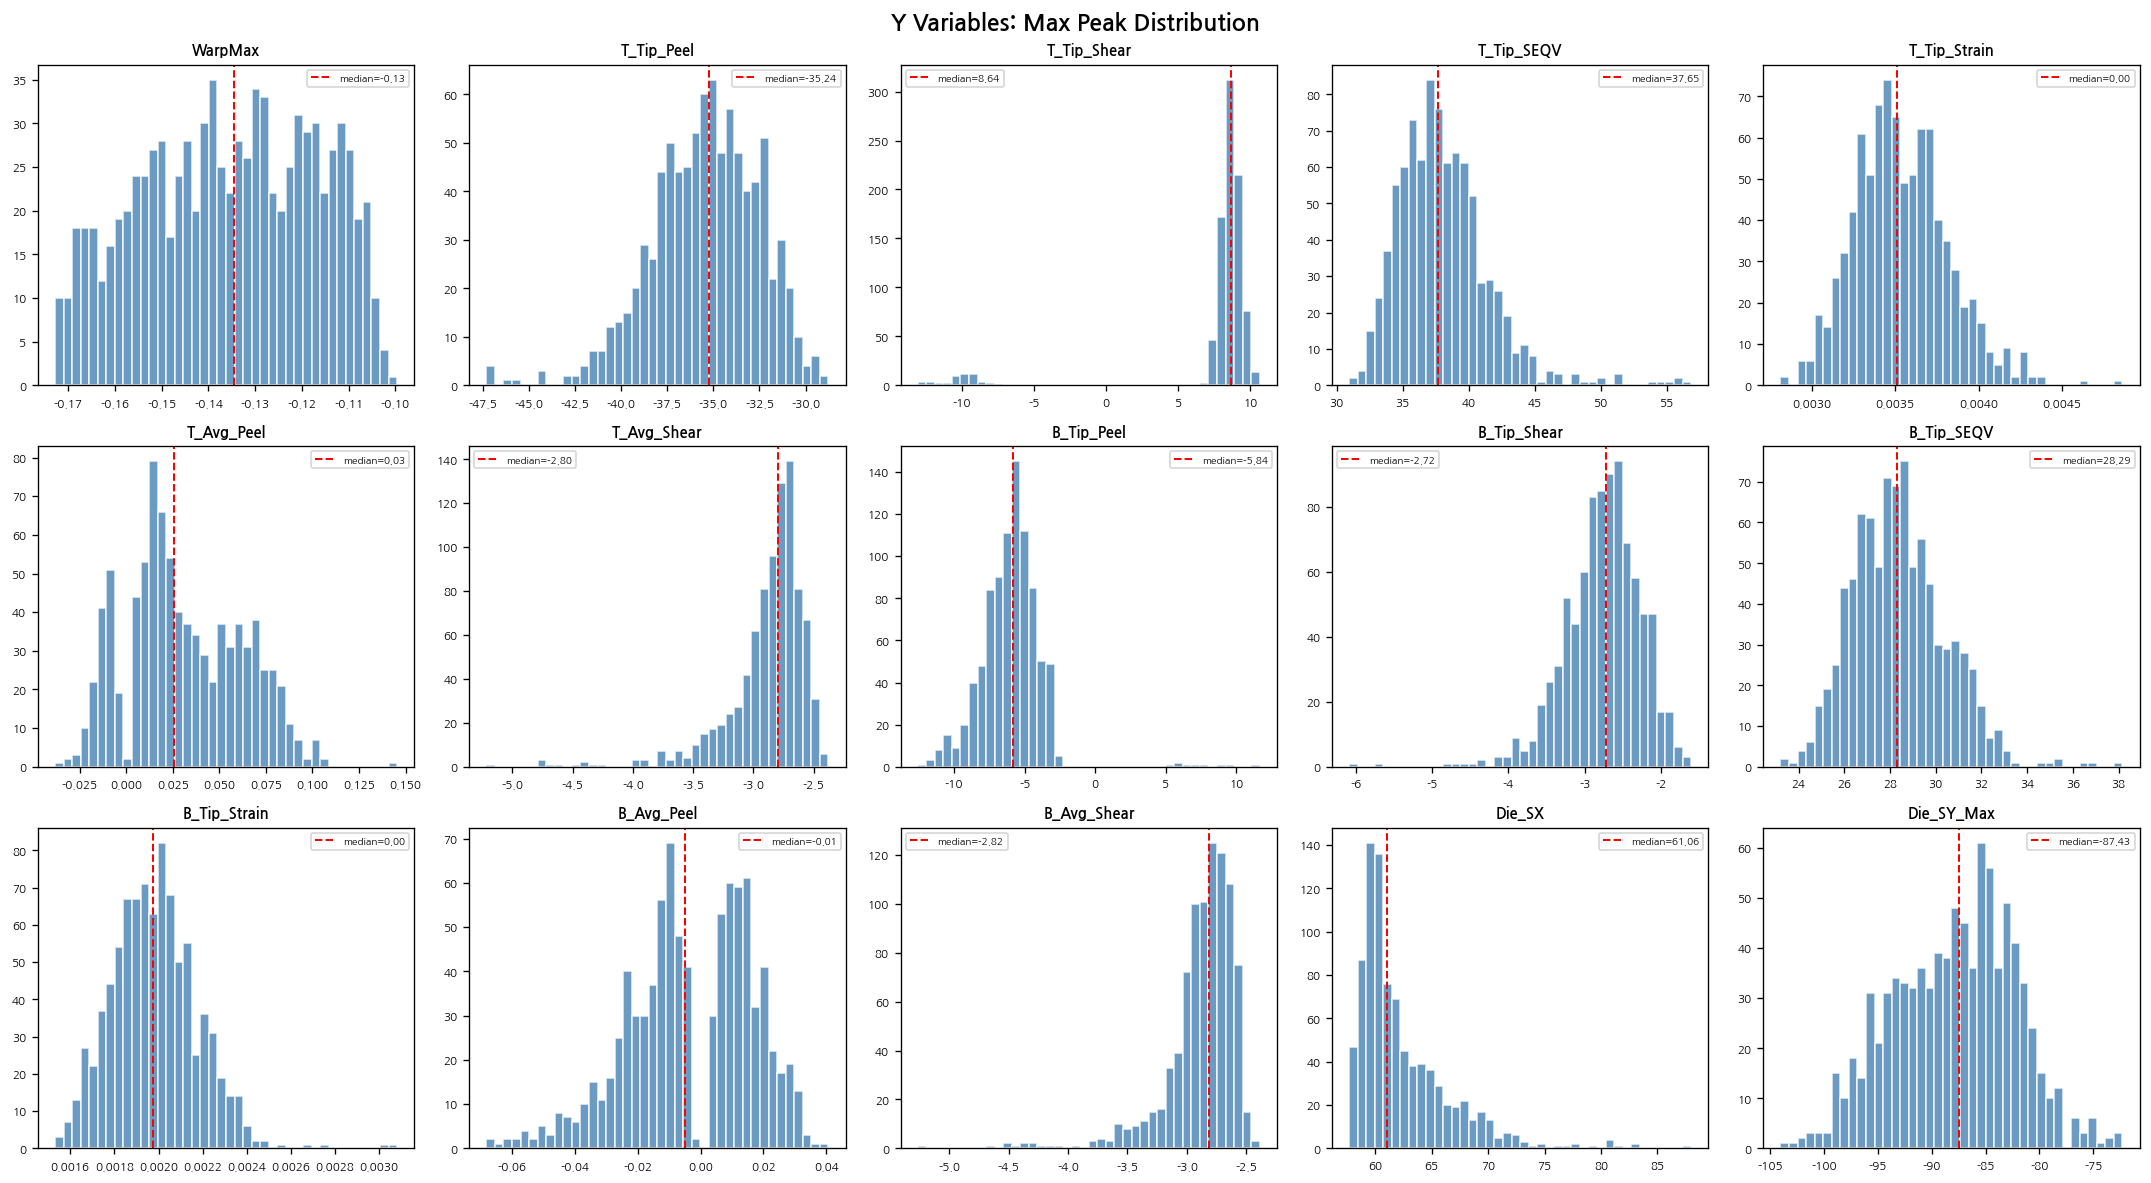

In [39]:
# == 3-2. Y 변수 피크값 분포 히스토그램 ==
# 각 응력/변형 채널의 피크 분포를 확인하여 편향(skew)이나 이상치 진단

fig, axes = plt.subplots(3, 5, figsize=(18, 10))
fig.suptitle('Y Variables: Max Peak Distribution', fontsize=14, fontweight='bold')

for idx, y_col in enumerate(Y_COLUMNS):
    ax = axes[idx // 5, idx % 5]
    data = df_peaks[y_col].dropna()
    
    # 히스토그램 + 중앙값 표시
    ax.hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(data.median(), color='red', linewidth=1.2, linestyle='--',
               label=f'median={data.median():.2f}')
    ax.set_title(y_col, fontsize=9, fontweight='bold')
    ax.legend(fontsize=6)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

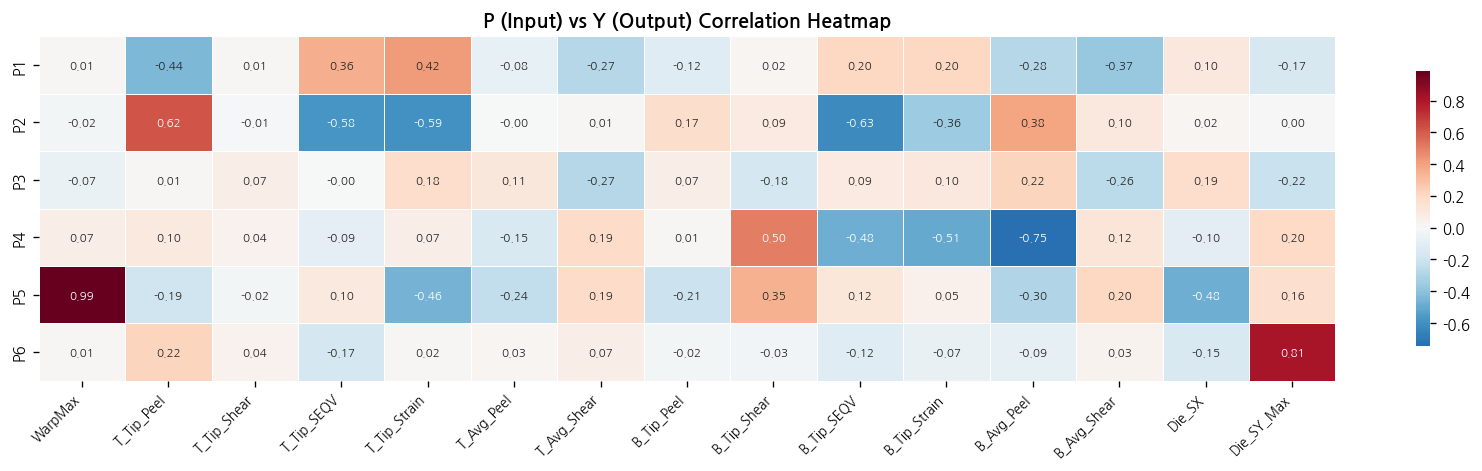


-- |상관계수| > 0.5인 강한 P-Y 관계 --
  P2 -> T_Tip_Peel: r=0.620 (양의 상관)
  P2 -> T_Tip_SEQV: r=-0.580 (음의 상관)
  P2 -> T_Tip_Strain: r=-0.593 (음의 상관)
  P2 -> B_Tip_SEQV: r=-0.628 (음의 상관)
  P4 -> B_Tip_Shear: r=0.504 (양의 상관)
  P4 -> B_Tip_Strain: r=-0.507 (음의 상관)
  P4 -> B_Avg_Peel: r=-0.747 (음의 상관)
  P5 -> WarpMax: r=0.987 (양의 상관)
  P6 -> Die_SY_Max: r=0.808 (양의 상관)


In [40]:
# == 3-3. P(입력) <-> Y(출력) 상관관계 히트맵 ==
# 어떤 두께 변수(P)가 어떤 응력(Y)에 강하게 영향을 미치는지 파악

p_cols = ['P1','P2','P3','P4','P5','P6']
corr_matrix = df_peaks[p_cols + Y_COLUMNS].corr()

# P vs Y 영역만 추출 (6 x 15 부분행렬)
corr_py = corr_matrix.loc[p_cols, Y_COLUMNS]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(corr_py, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 7},
            cbar_kws={'shrink': 0.8})
ax.set_title('P (Input) vs Y (Output) Correlation Heatmap', fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

# 상관관계가 강한 P-Y 조합 출력 (|r| > 0.5)
print('\n-- |상관계수| > 0.5인 강한 P-Y 관계 --')
for p in p_cols:
    for y in Y_COLUMNS:
        r = corr_py.loc[p, y]
        if abs(r) > 0.5:
            direction = '양' if r > 0 else '음'
            print(f'  {p} -> {y}: r={r:.3f} ({direction}의 상관)')

---
## 4. Gaussian Process Regression (GPR) 대리 모델 학습

### XGBoost에서 GPR로 변경한 이유
- XGBoost/LightGBM은 트리 기반 모델로, 학습 데이터 범위 경계에서 **리프 노드 평균값으로 수렴**하여
  분포 양 끝에 비정상적인 뿔(Spike)이 발생함 (구조적 한계, Optuna 튜닝으로도 해결 불가)
- GPR은 **연속 함수**로 예측하므로 경계에서 flat 수렴 없이 부드러운 분포 생성
- 예측값과 함께 **불확실성(σ)**을 출력하여 외삽 영역을 자동 감지 가능
- 데이터가 ~900개인 상황은 GPR의 최적 구간 (수천 개 이상이면 느려짐)

### 커널 선정
- `Matern(nu=2.5)`: 물리 시뮬레이션에 적합 (2차 미분 가능, 매끄러운 응력 곡면)
- `ConstantKernel`: 출력 스케일 자동 조정
- `WhiteKernel`: 관측 노이즈(시뮬레이션 메쉬 오차 등) 흡수

### 학습 전략
- 타겟별 개별 GPR 학습 (15개 독립 모델)
- **StandardScaler** 적용: GPR은 입력 스케일에 민감하므로 P1~P6를 정규화
- 5-Fold CV + 홀드아웃 Test로 성능 이중 검증

In [41]:
# == 4-1. X / Y 분리 및 Train / Test Split ==

X = df_peaks[['P1','P2','P3','P4','P5','P6']].copy()  # 입력: 6개 두께 변수
Y = df_peaks[Y_COLUMNS].copy()                         # 출력: 15개 응력/변형 피크

# 홀드아웃 테스트셋 15% 분리
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.15, random_state=SEED
)

# GPR은 입력 스케일에 민감 → StandardScaler로 P1~P6 정규화
# P1(0.80~1.10)과 P6(0.04~0.08)의 스케일 차이가 크므로 반드시 필요
scaler_X = StandardScaler()
X_train_sc = scaler_X.fit_transform(X_train)   # 학습 데이터 기준 fit + transform
X_test_sc  = scaler_X.transform(X_test)         # 테스트 데이터는 transform만

print(f'전체 데이터: {len(X)}개')
print(f'  +-- Train : {len(X_train)}개 (GPR 학습 + 5-Fold CV)')
print(f'  +-- Test  : {len(X_test)}개 (최종 성능 평가, 학습에 미사용)')
print(f'\\nStandardScaler 적용 완료 (GPR 입력 정규화)')

전체 데이터: 884개
  +-- Train : 751개 (GPR 학습 + 5-Fold CV)
  +-- Test  : 133개 (최종 성능 평가, 학습에 미사용)
\nStandardScaler 적용 완료 (GPR 입력 정규화)


In [42]:
# == 4-2. 타겟별 개별 GPR 학습 (체크포인트 지원) ==
import joblib

CHECKPOINT_DIR = os.path.join(BASE_DIR, 'checkpoints')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
GPR_CHECKPOINT = os.path.join(CHECKPOINT_DIR, 'gpr_models_ard.pkl')

if os.path.exists(GPR_CHECKPOINT):
    # ========== 체크포인트 로드 (학습 스킵) ==========
    print(f'기존 체크포인트 발견 → 로드 중: {GPR_CHECKPOINT}')
    ckpt = joblib.load(GPR_CHECKPOINT)
    models      = ckpt['models']
    cv_scores   = ckpt['cv_scores']
    test_scores = ckpt['test_scores']
    test_maes   = ckpt['test_maes']
    scaler_X    = ckpt['scaler_X']
    X_train     = ckpt['X_train']
    X_test      = ckpt['X_test']
    Y_train     = ckpt['Y_train']
    Y_test      = ckpt['Y_test']
    X_train_sc  = ckpt['X_train_sc']
    X_test_sc   = ckpt['X_test_sc']

    print(f'로드 완료! ({len(models)}개 모델)')
    for y_col in Y_COLUMNS:
        print(f'{y_col:15s} | CV R2={cv_scores[y_col]:.4f} | Test R2={test_scores[y_col]:.4f}')

    avg_cv = np.mean(list(cv_scores.values()))
    avg_test = np.mean(list(test_scores.values()))
    print(f'\n평균 CV R2: {avg_cv:.4f} / 평균 Test R2: {avg_test:.4f}')

else:
    # ========== 체크포인트 없음 → 신규 학습 ==========
    kernel_base = (
        ConstantKernel(1.0, (1e-3, 1e3))
        * Matern(
            nu=2.5,
            length_scale=np.ones(6),
            length_scale_bounds=(1e-2, 1e2)
        )
        + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-5, 1e1))
    )

    models = {}
    cv_scores = {}
    test_scores = {}
    test_maes = {}

    print('=== 타겟별 GPR 학습 시작 (체크포인트 없음 → 신규 학습) ===')
    print(f'커널: ConstantKernel * Matern(nu=2.5, ARD) + WhiteKernel')
    print(f'학습 데이터: {len(X_train)}개 (스케일링 적용)')
    print()

    t_start = time.time()

    for y_col in Y_COLUMNS:
        gpr = GaussianProcessRegressor(
            kernel=kernel_base,
            n_restarts_optimizer=10,
            alpha=1e-6,
            random_state=SEED
        )
        gpr.fit(X_train_sc, Y_train[y_col])

        kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
        cv_r2 = cross_val_score(
            GaussianProcessRegressor(
                kernel=kernel_base,
                n_restarts_optimizer=5,
                alpha=1e-6,
                random_state=SEED
            ),
            X_train_sc, Y_train[y_col],
            cv=kf, scoring='r2'
        )

        y_pred_test, y_std_test = gpr.predict(X_test_sc, return_std=True)
        if y_col in POSITIVE_ONLY_COLS:
            y_pred_test = np.clip(y_pred_test, 0, None)

        r2_test = r2_score(Y_test[y_col], y_pred_test)
        mae_test = mean_absolute_error(Y_test[y_col], y_pred_test)

        models[y_col] = gpr
        cv_scores[y_col] = cv_r2.mean()
        test_scores[y_col] = r2_test
        test_maes[y_col] = mae_test

        gap = abs(cv_r2.mean() - r2_test)
        flag = '  << OVERFIT?' if gap > 0.10 else ''
        print(f'{y_col:15s} | CV R2={cv_r2.mean():.4f} (+-{cv_r2.std():.4f}) | '
              f'Test R2={r2_test:.4f} | MAE={mae_test:.4f} | '
              f'mean_std={y_std_test.mean():.4f}{flag}')

    elapsed = time.time() - t_start
    print(f'\n=== 전체 학습 완료 ({elapsed:.1f}초 소요) ===')

    avg_cv = np.mean(list(cv_scores.values()))
    avg_test = np.mean(list(test_scores.values()))
    print(f'평균 CV R2: {avg_cv:.4f} / 평균 Test R2: {avg_test:.4f}')

    # ========== 체크포인트 저장 ==========
    checkpoint_data = {
        'models': models, 'cv_scores': cv_scores,
        'test_scores': test_scores, 'test_maes': test_maes,
        'scaler_X': scaler_X,
        'X_train': X_train, 'X_test': X_test,
        'Y_train': Y_train, 'Y_test': Y_test,
        'X_train_sc': X_train_sc, 'X_test_sc': X_test_sc,
    }
    joblib.dump(checkpoint_data, GPR_CHECKPOINT)
    print(f'\n체크포인트 저장 완료: {GPR_CHECKPOINT}')
    print(f'파일 크기: {os.path.getsize(GPR_CHECKPOINT) / 1024 / 1024:.1f} MB')
    print('(다음 실행 시 자동 로드되어 ~24분 학습 생략)')

기존 체크포인트 발견 → 로드 중: /mnt/i/ai_model_dev/cfd/checkpoints/gpr_models_ard.pkl
로드 완료! (15개 모델)
WarpMax         | CV R2=0.9992 | Test R2=0.9995
T_Tip_Peel      | CV R2=0.7436 | Test R2=0.4872
T_Tip_Shear     | CV R2=-0.2077 | Test R2=-0.0661
T_Tip_SEQV      | CV R2=0.5645 | Test R2=0.3296
T_Tip_Strain    | CV R2=0.8171 | Test R2=0.7403
T_Avg_Peel      | CV R2=0.0637 | Test R2=0.0121
T_Avg_Shear     | CV R2=0.2312 | Test R2=0.1712
B_Tip_Peel      | CV R2=0.1128 | Test R2=0.1001
B_Tip_Shear     | CV R2=0.4323 | Test R2=0.3672
B_Tip_SEQV      | CV R2=0.8350 | Test R2=0.7497
B_Tip_Strain    | CV R2=0.4671 | Test R2=0.4275
B_Avg_Peel      | CV R2=0.8190 | Test R2=0.8287
B_Avg_Shear     | CV R2=0.2947 | Test R2=0.2165
Die_SX          | CV R2=0.4072 | Test R2=0.2590
Die_SY_Max      | CV R2=0.8343 | Test R2=0.8619

평균 CV R2: 0.4943 / 평균 Test R2: 0.4323


In [43]:
# == 4-2b. GPR 모델 체크포인트 저장/로드 ==
# GPR 학습에 ~24분 소요되므로, 학습 완료 후 저장해두고 이후 실행 시 로드하여 스킵
import joblib

CHECKPOINT_DIR = os.path.join(BASE_DIR, 'checkpoints')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
GPR_CHECKPOINT = os.path.join(CHECKPOINT_DIR, 'gpr_models_ard.pkl')

# 저장할 객체를 하나의 딕셔너리로 묶음
checkpoint_data = {
    'models': models,
    'cv_scores': cv_scores,
    'test_scores': test_scores,
    'test_maes': test_maes,
    'scaler_X': scaler_X,
    'X_train': X_train,
    'X_test': X_test,
    'Y_train': Y_train,
    'Y_test': Y_test,
    'X_train_sc': X_train_sc,
    'X_test_sc': X_test_sc,
}

joblib.dump(checkpoint_data, GPR_CHECKPOINT)
print(f'체크포인트 저장 완료: {GPR_CHECKPOINT}')
print(f'파일 크기: {os.path.getsize(GPR_CHECKPOINT) / 1024 / 1024:.1f} MB')

체크포인트 저장 완료: /mnt/i/ai_model_dev/cfd/checkpoints/gpr_models_ard.pkl
파일 크기: 65.5 MB


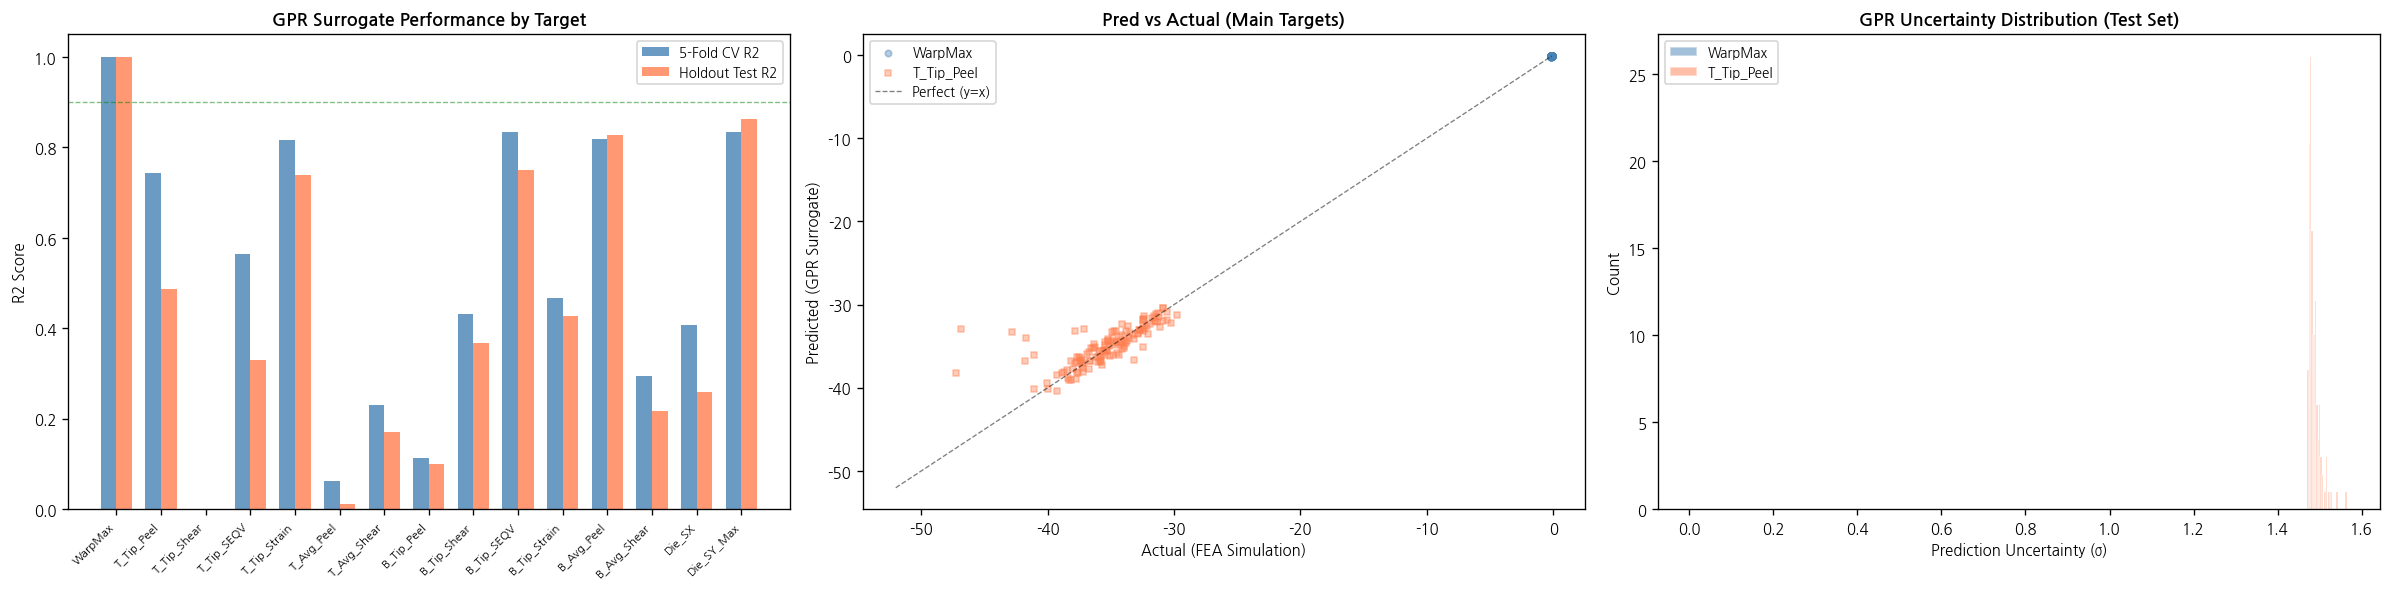

In [44]:
# == 4-3. 모델 성능 시각화 ==

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# --- (A) 변수별 R2 비교 바 차트 (CV vs Test) ---
ax = axes[0]
x_pos = np.arange(len(Y_COLUMNS))
width = 0.35

ax.bar(x_pos - width/2, [cv_scores[c] for c in Y_COLUMNS], width,
       label='5-Fold CV R2', color='steelblue', alpha=0.8)
ax.bar(x_pos + width/2, [test_scores[c] for c in Y_COLUMNS], width,
       label='Holdout Test R2', color='coral', alpha=0.8)

ax.set_xticks(x_pos)
ax.set_xticklabels(Y_COLUMNS, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('R2 Score')
ax.set_title('GPR Surrogate Performance by Target', fontweight='bold')
ax.legend(fontsize=8)
ax.axhline(0.9, color='green', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_ylim(0, 1.05)

# --- (B) Pred vs Actual 산점도 (메인 타겟 2개) ---
ax = axes[1]
for y_col, color, marker in [('WarpMax', 'steelblue', 'o'), ('T_Tip_Peel', 'coral', 's')]:
    y_actual = Y_test[y_col].values
    y_pred, y_std = models[y_col].predict(X_test_sc, return_std=True)
    if y_col in POSITIVE_ONLY_COLS:
        y_pred = np.clip(y_pred, 0, None)
    ax.scatter(y_actual, y_pred, alpha=0.4, s=15, c=color, marker=marker, label=y_col)

all_vals = np.concatenate([Y_test['WarpMax'].values, Y_test['T_Tip_Peel'].values])
lims = [all_vals.min() * 1.1, all_vals.max() * 1.1]
ax.plot(lims, lims, 'k--', linewidth=0.8, alpha=0.5, label='Perfect (y=x)')
ax.set_xlabel('Actual (FEA Simulation)')
ax.set_ylabel('Predicted (GPR Surrogate)')
ax.set_title('Pred vs Actual (Main Targets)', fontweight='bold')
ax.legend(fontsize=8)

# --- (C) GPR 불확실성(σ) 분포 (GPR 고유 장점) ---
# 불확실성이 높은 예측 = 외삽 영역 → 신뢰도 낮음
ax = axes[2]
for y_col, color in [('WarpMax', 'steelblue'), ('T_Tip_Peel', 'coral')]:
    _, y_std = models[y_col].predict(X_test_sc, return_std=True)
    ax.hist(y_std, bins=30, alpha=0.5, color=color, edgecolor='white', label=y_col)
ax.set_xlabel('Prediction Uncertainty (σ)')
ax.set_ylabel('Count')
ax.set_title('GPR Uncertainty Distribution (Test Set)', fontweight='bold')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

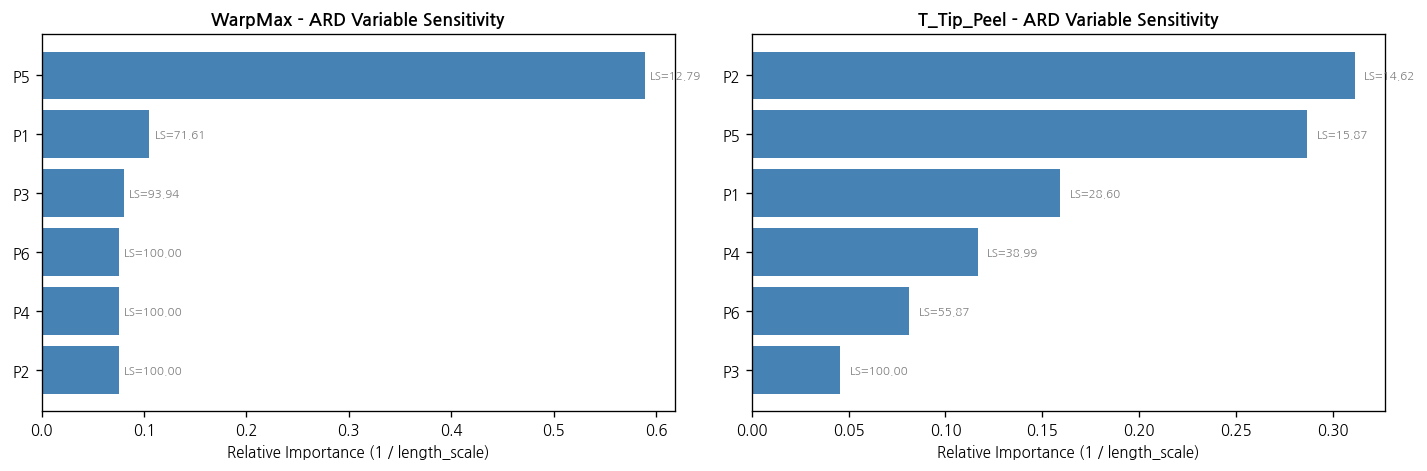


WarpMax 학습된 length_scale:
  P1: 71.6132 (중요도 ∝ 1/71.6132 = 0.0140)
  P2: 100.0000 (중요도 ∝ 1/100.0000 = 0.0100)
  P3: 93.9358 (중요도 ∝ 1/93.9358 = 0.0106)
  P4: 100.0000 (중요도 ∝ 1/100.0000 = 0.0100)
  P5: 12.7943 (중요도 ∝ 1/12.7943 = 0.0782)
  P6: 100.0000 (중요도 ∝ 1/100.0000 = 0.0100)

T_Tip_Peel 학습된 length_scale:
  P1: 28.5976 (중요도 ∝ 1/28.5976 = 0.0350)
  P2: 14.6187 (중요도 ∝ 1/14.6187 = 0.0684)
  P3: 100.0000 (중요도 ∝ 1/100.0000 = 0.0100)
  P4: 38.9933 (중요도 ∝ 1/38.9933 = 0.0256)
  P5: 15.8741 (중요도 ∝ 1/15.8741 = 0.0630)
  P6: 55.8743 (중요도 ∝ 1/55.8743 = 0.0179)


In [45]:
# == 4-4. GPR 기반 변수 중요도 (ARD 커널 Length Scale) ==
# ARD Matern 커널이 변수별로 학습한 length_scale의 역수 = 변수 민감도
# length_scale이 작을수록 → 해당 변수의 작은 변화에도 출력이 크게 반응 → 중요도 높음

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_col in zip(axes, ['WarpMax', 'T_Tip_Peel']):
    learned_kernel = models[y_col].kernel_
    matern_kernel = learned_kernel.k1.k2  # ConstantKernel * Matern 중 Matern 추출
    length_scales = np.array(matern_kernel.length_scale)
    
    # 역수 → 정규화하여 상대 중요도로 변환
    importance = 1.0 / length_scales
    importance = importance / importance.sum()
    
    # 중요도 내림차순 정렬
    p_labels = ['P1','P2','P3','P4','P5','P6']
    sorted_idx = np.argsort(importance)
    sorted_labels = [p_labels[i] for i in sorted_idx]
    sorted_importance = importance[sorted_idx]
    
    ax.barh(sorted_labels, sorted_importance, color='steelblue')
    ax.set_xlabel('Relative Importance (1 / length_scale)')
    ax.set_title(f'{y_col} - ARD Variable Sensitivity', fontweight='bold')
    
    # 각 변수의 실제 length_scale 값도 표시
    for i, (label, imp) in enumerate(zip(sorted_labels, sorted_importance)):
        ls_val = length_scales[p_labels.index(label)]
        ax.text(imp + 0.005, i, f'LS={ls_val:.2f}', va='center', fontsize=7, color='gray')

plt.tight_layout()
plt.show()

# 학습된 length_scale 상세 출력
for y_col in ['WarpMax', 'T_Tip_Peel']:
    ls = models[y_col].kernel_.k1.k2.length_scale
    print(f'\n{y_col} 학습된 length_scale:')
    for p, l in zip(['P1','P2','P3','P4','P5','P6'], ls):
        print(f'  {p}: {l:.4f} (중요도 ∝ 1/{l:.4f} = {1/l:.4f})')

---
## 5. 몬테카를로 난수 생성 및 10만 개 가상 데이터 증강

학습된 XGBoost 대리 모델로 **10만 개의 가상 P1~P6 조합**에 대한 Y값을 예측합니다.

### 난수 생성 방식: Latin Hypercube Sampling (LHS)
- 단순 `np.random.uniform`보다 6차원 설계 공간을 **더 균일하게 커버**
- 각 차원을 N개 구간으로 분할 후 구간당 1개씩 배치 (층화 샘플링)
- 동일 샘플 수 대비 사각지대(dead zone) 없이 골고루 분포

In [46]:
# == 5-1. Latin Hypercube Sampling (LHS)으로 10만 개 P1~P6 생성 ==

N_VIRTUAL = 100_000  # 생성할 가상 데이터 수

def latin_hypercube_sampling(n_samples, n_dims, seed=42):
    """
    Latin Hypercube Sampling (LHS) 구현
    
    원리:
    - [0, 1] 범위를 n_samples개의 균등 구간으로 분할
    - 각 차원에서 한 구간당 정확히 하나의 샘플을 배치 (층화 샘플링)
    - 차원별로 독립적으로 셔플하여 조합
    
    Parameters:
        n_samples: 생성할 샘플 수
        n_dims: 차원 수 (변수 수)
        seed: 난수 시드
    Returns:
        (n_samples, n_dims) numpy 배열, 값 범위 [0, 1]
    """
    rng = np.random.RandomState(seed)
    result = np.zeros((n_samples, n_dims))
    
    for dim in range(n_dims):
        # 각 구간 내에서의 랜덤 오프셋 생성
        perms = rng.permutation(n_samples)  # 구간 순서 셔플
        # (구간 번호 + 랜덤 오프셋) / 총 구간 수 -> [0, 1] 범위로 정규화
        result[:, dim] = (perms + rng.uniform(size=n_samples)) / n_samples
    
    return result

# [0,1]^6 범위 LHS 생성
lhs_raw = latin_hypercube_sampling(N_VIRTUAL, n_dims=6, seed=SEED)

# 각 P 변수의 실제 min/max 바운더리로 스케일링
# 바운더리는 마스터 DOE 전체 1200개 기준 (생존 데이터가 아닌 원본 전체)
p_cols = ['P1','P2','P3','P4','P5','P6']
virtual_X_dict = {}

print(f'-- {N_VIRTUAL:,}개 가상 P1~P6 생성 (LHS) --')
print(f'{"변수":>5s} | {"Min":>8s} | {"Max":>8s}')
print('-' * 30)

for i, p in enumerate(p_cols):
    lo = df_master[p].min()   # 마스터 DOE 전체의 최솟값
    hi = df_master[p].max()   # 마스터 DOE 전체의 최댓값
    
    # [0,1] -> [min, max] 선형 변환
    virtual_X_dict[p] = lo + (hi - lo) * lhs_raw[:, i]
    print(f'{p:>5s} | {lo:8.4f} | {hi:8.4f}')

df_virtual_X = pd.DataFrame(virtual_X_dict)
print(f'\n{N_VIRTUAL:,}개 가상 P1~P6 조합 생성 완료')
display(df_virtual_X.describe().round(4))

-- 100,000개 가상 P1~P6 생성 (LHS) --
   변수 |      Min |      Max
------------------------------
   P1 |   0.8005 |   1.0998
   P2 |   0.0500 |   0.0899
   P3 |   0.6001 |   0.7198
   P4 |   0.1000 |   0.2994
   P5 |   1.2003 |   1.7997
   P6 |   0.0401 |   0.0800

100,000개 가상 P1~P6 조합 생성 완료


,P1,P2,P3,P4,P5,P6
count,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000
mean,0.9502,0.0699,0.6600,0.1997,1.5000,0.0600
std,0.0864,0.0115,0.0346,0.0576,0.1730,0.0115
min,0.8005,0.0500,0.6001,0.1000,1.2003,0.0401
25%,0.8753,0.0600,0.6300,0.1499,1.3502,0.0501
50%,0.9502,0.0700,0.6599,0.1997,1.5000,0.0600
75%,1.0250,0.0799,0.6899,0.2495,1.6498,0.0700
max,1.0998,0.0899,0.7198,0.2994,1.7997,0.0800


In [47]:
# == 5-2. GPR 대리 모델로 10만 개 Y값 예측 ==

# 가상 P1~P6도 동일한 StandardScaler로 변환
X_virtual_sc = scaler_X.transform(df_virtual_X)

print(f'학습된 GPR로 {N_VIRTUAL:,}개의 Y 값 예측 중...')
print('(GPR 예측은 XGBoost보다 느릴 수 있음, 타겟당 수 초~수십 초 소요)')
t_start = time.time()

virtual_Y_dict = {}
virtual_std_dict = {}  # 불확실성도 함께 저장

for y_col in Y_COLUMNS:
    t_col = time.time()
    
    # GPR 예측: 평균값 + 불확실성(σ)
    y_pred, y_std = models[y_col].predict(X_virtual_sc, return_std=True)
    
    # 물리적 음수 방지: SEQV, Strain은 정의상 항상 >= 0
    if y_col in POSITIVE_ONLY_COLS:
        y_pred = np.clip(y_pred, 0, None)
    
    virtual_Y_dict[y_col] = y_pred
    virtual_std_dict[y_col + '_std'] = y_std
    
    print(f'  {y_col:15s} 완료 ({time.time()-t_col:.1f}초) | '
          f'mean_std={y_std.mean():.4f}, max_std={y_std.max():.4f}')

df_virtual_Y = pd.DataFrame(virtual_Y_dict)
df_virtual_std = pd.DataFrame(virtual_std_dict)  # 불확실성 별도 저장 (선택적 활용)

elapsed = time.time() - t_start
print(f'\\n예측 완료! (총 {elapsed:.1f}초 소요)')
print(f'평균 불확실성(σ)이 높은 상위 3개 변수:')
mean_stds = {col: df_virtual_std[col+'_std'].mean() for col in Y_COLUMNS}
for col, std in sorted(mean_stds.items(), key=lambda x: x[1], reverse=True)[:3]:
    print(f'  {col}: mean σ = {std:.4f}')

학습된 GPR로 100,000개의 Y 값 예측 중...
(GPR 예측은 XGBoost보다 느릴 수 있음, 타겟당 수 초~수십 초 소요)
  WarpMax         완료 (1.9초) | mean_std=0.0032, max_std=0.0034
  T_Tip_Peel      완료 (1.6초) | mean_std=1.4912, max_std=1.6539
  T_Tip_Shear     완료 (1.8초) | mean_std=3.6613, max_std=5.1029
  T_Tip_SEQV      완료 (1.8초) | mean_std=2.1476, max_std=2.6489
  T_Tip_Strain    완료 (1.5초) | mean_std=0.0032, max_std=0.0032
  T_Avg_Peel      완료 (1.8초) | mean_std=0.0296, max_std=0.0306
  T_Avg_Shear     완료 (1.3초) | mean_std=0.2771, max_std=0.2864
  B_Tip_Peel      완료 (1.5초) | mean_std=2.0306, max_std=2.3346
  B_Tip_Shear     완료 (1.8초) | mean_std=0.3605, max_std=0.4079
  B_Tip_SEQV      완료 (1.8초) | mean_std=0.8039, max_std=1.0164
  B_Tip_Strain    완료 (1.5초) | mean_std=0.0032, max_std=0.0032
  B_Avg_Peel      완료 (1.8초) | mean_std=0.0084, max_std=0.0095
  B_Avg_Shear     완료 (1.8초) | mean_std=0.2389, max_std=0.2458
  Die_SX          완료 (1.5초) | mean_std=3.0039, max_std=3.1984
  Die_SY_Max      완료 (1.4초) | mean_std=2.2755, max_std=4

In [48]:
# == 5-3. 예측 결과 물리적 범위 검증 ==
# 대리 모델이 외삽(extrapolation)하여 비현실적인 값을 예측했는지 검증
# 실제 데이터 범위 +- 20% 마진을 허용 범위로 설정

print('=== 예측 데이터 물리적 범위 검증 ===')
print(f'{"변수":15s} | {"실제 Min":>12s} | {"실제 Max":>12s} | '
      f'{"예측 Min":>12s} | {"예측 Max":>12s} | 이탈률')
print('-' * 90)

outlier_flags = pd.Series(False, index=df_virtual_Y.index)

for y_col in Y_COLUMNS:
    actual_min = df_peaks[y_col].min()
    actual_max = df_peaks[y_col].max()
    pred_min = df_virtual_Y[y_col].min()
    pred_max = df_virtual_Y[y_col].max()
    
    # 실제 범위의 20% 마진을 허용 범위로 설정
    margin = (actual_max - actual_min) * 0.20
    safe_lo = actual_min - margin
    safe_hi = actual_max + margin
    
    # 허용 범위를 벗어나는 예측값 탐지
    out_mask = (df_virtual_Y[y_col] < safe_lo) | (df_virtual_Y[y_col] > safe_hi)
    outlier_flags = outlier_flags | out_mask
    n_out = out_mask.sum()
    pct = n_out / len(df_virtual_Y) * 100
    
    flag = '  <<' if pct > 5 else ''
    print(f'{y_col:15s} | {actual_min:12.4f} | {actual_max:12.4f} | '
          f'{pred_min:12.4f} | {pred_max:12.4f} | {pct:5.2f}%{flag}')

n_outlier = outlier_flags.sum()
print(f'\n범위 이탈 샘플 총합: {n_outlier:,}개 ({n_outlier/len(df_virtual_Y)*100:.2f}%)')
print('(이탈 샘플이 많으면 모델 과적합 또는 외삽 위험)')
print('-> Step 2 Gatekeeper 분류기에서 물리적으로 불안전한 조합은 추가 필터링 예정')

=== 예측 데이터 물리적 범위 검증 ===
변수              |       실제 Min |       실제 Max |       예측 Min |       예측 Max | 이탈률
------------------------------------------------------------------------------------------
WarpMax         |      -0.1728 |      -0.0996 |      -0.1777 |      -0.0979 |  0.00%
T_Tip_Peel      |     -47.2917 |     -28.7603 |     -43.1654 |     -29.0452 |  0.00%
T_Tip_Shear     |     -13.0566 |      10.6679 |      -2.7461 |      11.4659 |  0.00%
T_Tip_SEQV      |      30.9377 |      56.8349 |      30.1214 |      46.9710 |  0.00%
T_Tip_Strain    |       0.0028 |       0.0049 |       0.0027 |       0.0043 |  0.00%
T_Avg_Peel      |      -0.0382 |       0.1454 |      -0.0011 |       0.0472 |  0.00%
T_Avg_Shear     |      -5.2160 |      -2.3780 |      -3.5925 |      -2.4794 |  0.00%
B_Tip_Peel      |     -12.5674 |      11.6636 |     -11.0905 |      -3.7334 |  0.00%
B_Tip_Shear     |      -6.0878 |      -1.6034 |      -3.9933 |      -1.6079 |  0.00%
B_Tip_SEQV      |      23.2101 |     

In [49]:
# == 5-4. 증강 데이터 병합 및 CSV 저장 ==

# X(입력: P1~P6)와 예측된 Y(출력: 15개 응력/변형 피크) 병합
df_augmented = pd.concat([df_virtual_X, df_virtual_Y], axis=1)

# 가상 데이터 식별용 ID 부여 (원본과 구분)
df_augmented.insert(0, 'Row_ID', [f'Virtual_{i+1}' for i in range(N_VIRTUAL)])

# CSV 저장
output_file = 'Augmented_100k_Data.csv'
df_augmented.to_csv(output_file, index=False)

print(f'=== 증강 데이터 저장 완료 ===')
print(f'파일명: {output_file}')
print(f'크기: {df_augmented.shape[0]:,}행 x {df_augmented.shape[1]}열')
print(f'컬럼: Row_ID + P1~P6 (6) + Y변수 ({len(Y_COLUMNS)}) = {1+6+len(Y_COLUMNS)}열')
print()
display(df_augmented.head())

=== 증강 데이터 저장 완료 ===
파일명: Augmented_100k_Data.csv
크기: 100,000행 x 22열
컬럼: Row_ID + P1~P6 (6) + Y변수 (15) = 22열



,Row_ID,P1,P2,P3,P4,P5,P6,WarpMax,T_Tip_Peel,T_Tip_Shear,...,T_Avg_Peel,T_Avg_Shear,B_Tip_Peel,B_Tip_Shear,B_Tip_SEQV,B_Tip_Strain,B_Avg_Peel,B_Avg_Shear,Die_SX,Die_SY_Max
0,Virtual_1,1.027135,0.087445,0.658718,0.231420,1.685991,0.052563,-0.116210,-34.119543,7.804664,...,0.013239,-2.846752,-5.577556,-2.058820,25.054773,0.001793,-0.017990,-2.838834,61.276537,-91.910840
1,Virtual_2,1.040493,0.076397,0.628455,0.214296,1.579394,0.077707,-0.123427,-34.067173,6.917368,...,0.020510,-2.777226,-5.837076,-2.355927,26.525788,0.001899,-0.020959,-2.826672,60.033153,-81.459955
2,Virtual_3,0.859955,0.086767,0.655392,0.189343,1.779187,0.066959,-0.104475,-32.462063,7.474840,...,0.020288,-2.711263,-5.283604,-2.498303,26.719174,0.001823,-0.002263,-2.647969,59.271202,-82.429602
3,Virtual_4,1.030061,0.065772,0.626600,0.236199,1.400582,0.046464,-0.144742,-37.251620,8.771176,...,0.027037,-2.949802,-4.997569,-2.429755,27.846909,0.001927,-0.026023,-2.997550,63.309357,-97.192471
4,Virtual_5,1.078823,0.057586,0.608553,0.295215,1.325479,0.077874,-0.150454,-38.221955,9.167565,...,0.017832,-2.913062,-7.126786,-2.503688,27.529787,0.001863,-0.050009,-3.031129,61.948597,-81.017870


---
## 6. 증강 데이터 품질 검증 (Sanity Check)

증강된 10만 개 데이터의 분포가 원본 ~900개와 일관성이 있는지 시각적으로 검증합니다.

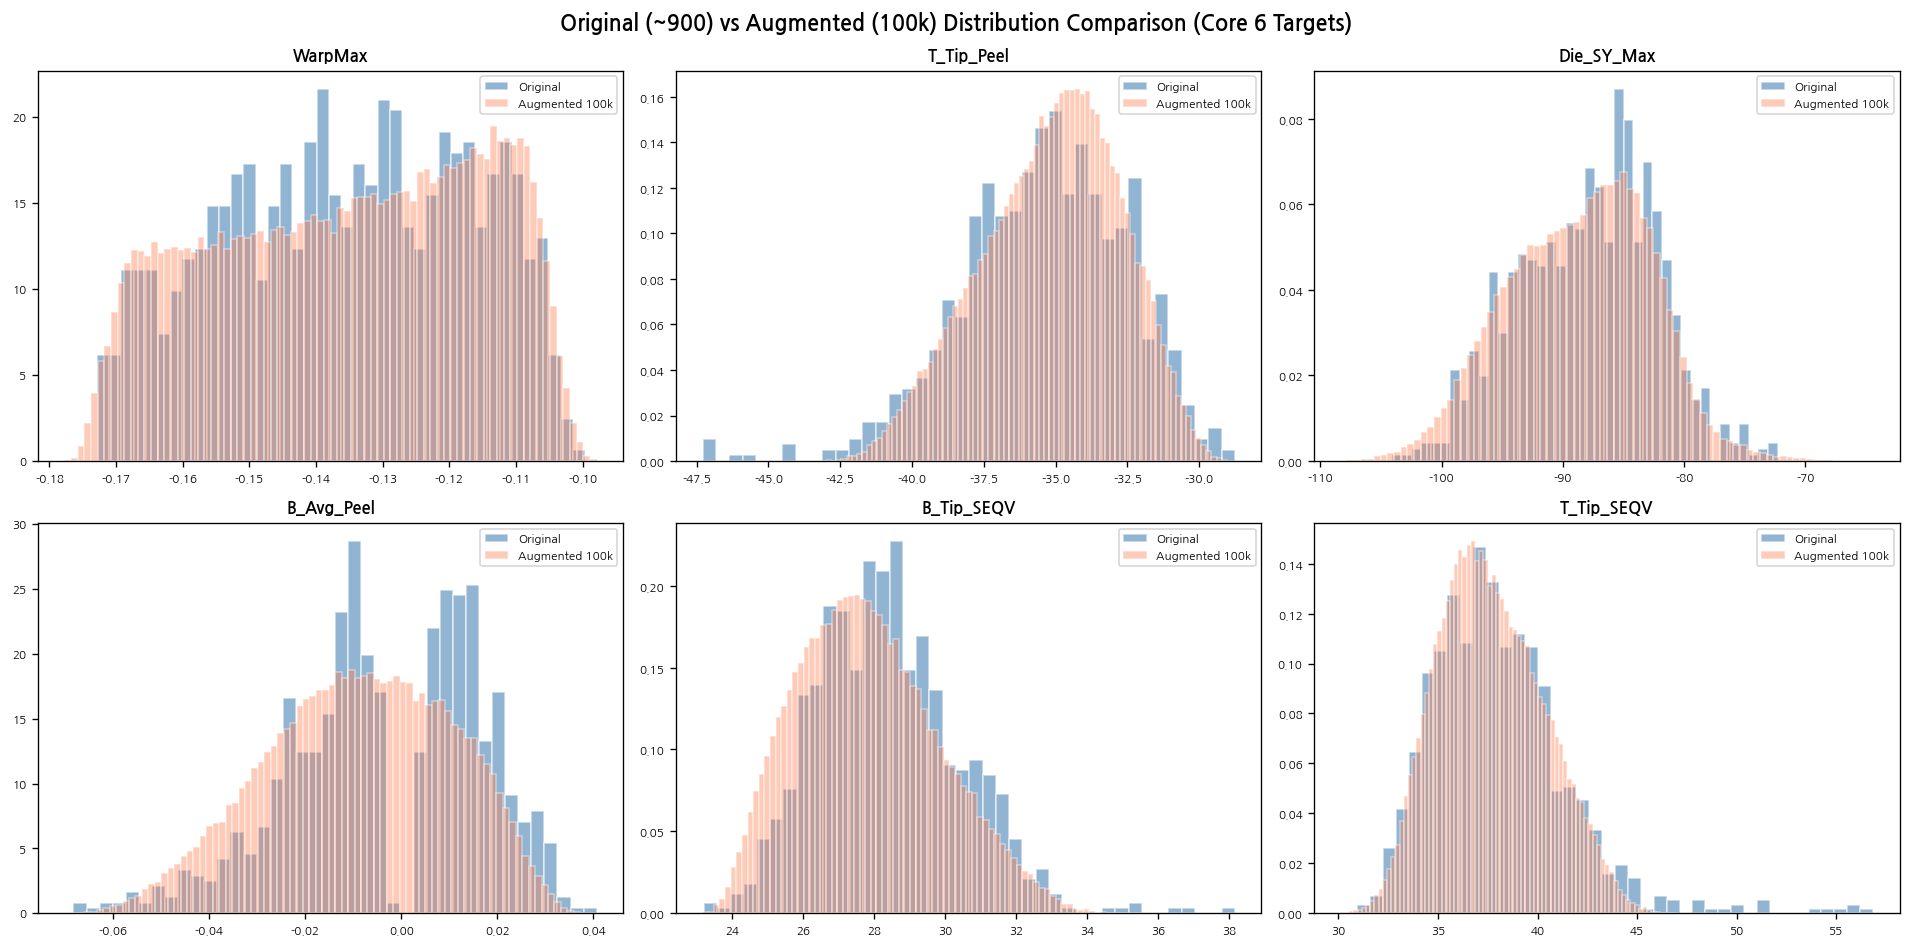

* 분포가 대체로 일치하면 -> 대리 모델이 원본 경향을 잘 학습한 것
* 분포가 크게 다르면 -> 과적합/외삽 위험 -> 하이퍼파라미터 재조정 필요
* (참고: 증강 데이터 양 끝단의 비정상적인 뿔(Spike)은 Step 2 Gatekeeper에서 제거됩니다.)


In [50]:
# == 6-1. 원본 vs 증강 분포 비교 (주요 6대 핵심 변수) ==

# R2 점수가 검증된 6대 핵심 타겟으로 변경 (노이즈 변수 배제)
check_cols = ['WarpMax', 'T_Tip_Peel', 'Die_SY_Max', 
              'B_Avg_Peel', 'B_Tip_SEQV', 'T_Tip_SEQV']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Original (~900) vs Augmented (100k) Distribution Comparison (Core 6 Targets)',
             fontsize=13, fontweight='bold')

for idx, y_col in enumerate(check_cols):
    ax = axes[idx // 3, idx % 3]
    
    # 원본 데이터 분포 (파란색 히스토그램)
    ax.hist(df_peaks[y_col], bins=40, density=True, alpha=0.6,
            color='steelblue', edgecolor='white', label='Original')
    
    # 증강 데이터 분포 (빨간색 히스토그램, 더 세밀한 bin)
    ax.hist(df_augmented[y_col], bins=80, density=True, alpha=0.4,
            color='coral', edgecolor='white', label='Augmented 100k')
    
    ax.set_title(y_col, fontweight='bold', fontsize=10)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

print('* 분포가 대체로 일치하면 -> 대리 모델이 원본 경향을 잘 학습한 것')
print('* 분포가 크게 다르면 -> 과적합/외삽 위험 -> 하이퍼파라미터 재조정 필요')
print('* (참고: 증강 데이터 양 끝단의 비정상적인 뿔(Spike)은 Step 2 Gatekeeper에서 제거됩니다.)')

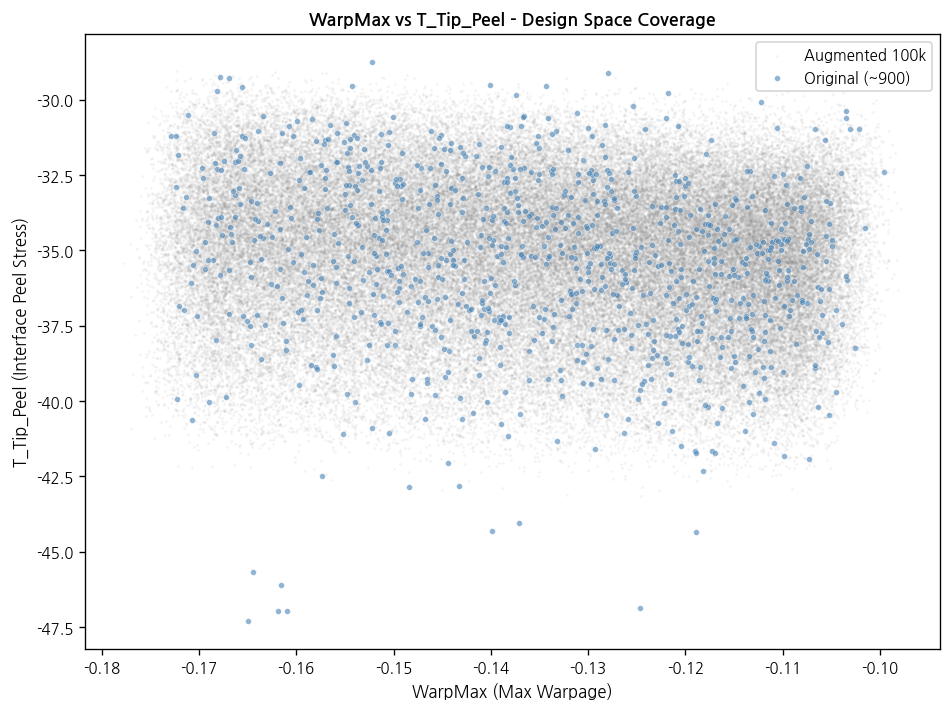

-> 이 2D 공간에서 좌측 하단(WarpMax 작고, T_Tip_Peel 작은)이 이상적인 설계
-> Step 3에서 파레토 프론티어(비지배 해 집합)를 추출할 영역


In [51]:
# == 6-2. 메인 타겟 2D 산점도 (WarpMax vs T_Tip_Peel) ==
# Step 3 파레토 프론티어에서 사용할 두 축의 공간 분포 확인

fig, ax = plt.subplots(figsize=(8, 6))

# 증강 데이터 (배경: 회색, 매우 투명하게)
ax.scatter(df_augmented['WarpMax'], df_augmented['T_Tip_Peel'],
           s=1, alpha=0.05, c='gray', label='Augmented 100k')

# 원본 데이터 (전경: 파란색, 선명하게)
ax.scatter(df_peaks['WarpMax'], df_peaks['T_Tip_Peel'],
           s=12, alpha=0.6, c='steelblue', edgecolors='white',
           linewidths=0.3, label='Original (~900)')

ax.set_xlabel('WarpMax (Max Warpage)', fontsize=10)
ax.set_ylabel('T_Tip_Peel (Interface Peel Stress)', fontsize=10)
ax.set_title('WarpMax vs T_Tip_Peel - Design Space Coverage', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('-> 이 2D 공간에서 좌측 하단(WarpMax 작고, T_Tip_Peel 작은)이 이상적인 설계')
print('-> Step 3에서 파레토 프론티어(비지배 해 집합)를 추출할 영역')

---
## Step 1 완료 요약

| 항목 | 결과 |
|------|------|
| 원본 생존 데이터 | ~900개 DP (1200 중 ~71%) |
| 추출 지표 | 15개 Y변수의 절댓값 Max Peak (부호 유지) |
| 대리 모델 | 타겟별 개별 XGBoost (Early Stopping + 5-Fold CV) |
| 증강 데이터 | **100,000개** (`Augmented_100k_Data.csv`) |
| 난수 생성 | Latin Hypercube Sampling (균등 공간 충전) |

## [Step 2] 은닉 제약조건 분류기(Gatekeeper)를 통한 필터링

### 목표
물리적으로 파괴되는(해석이 터지는) 치수 조합을 사전에 걸러낸다.
### 라벨링 로직
시계열 CSV 폴더(`SIM_CSV_DATA`)에서 `ML_DATA_Extract_Row_{Row_ID}.csv`를 스캔하여:
- 파일이 **존재하는** Row_ID → `is_safe = 1` (Safe)
- 파일이 **누락된** Row_ID → `is_safe = 0` (Fail, 시뮬레이션 발산)
전체 DP 수는 폴더 내 **가장 큰 Row_ID**를 기준으로 산정한다.
각 Row_ID는 `Master_DOE_1200.csv`의 행과 1:1 매칭된다.
(CSV 1행 = 헤더, 2행 = Row_ID 1, 3행 = Row_ID 2, ...)
```
Master_DOE_1200.csv 행 매칭:
  2행 (iloc[0]) → Row_ID = 1 → ML_DATA_Extract_Row_1.csv 존재 여부 확인
  3행 (iloc[1]) → Row_ID = 2 → ML_DATA_Extract_Row_2.csv 존재 여부 확인
  ...
```
### 분류기
- **Random Forest** (n_estimators=300, max_depth=7, class_weight='balanced')
- 입력: P1~P6 (6개 두께 변수)
- 출력: 0(Fail) / 1(Safe) 이진 분류
- 성능 평가: 5-Fold Stratified CV (F1, Accuracy) + OOB Score
### 필터링 흐름
```
Augmented_100k_Data.csv (10만 행)
    ↓ P1~P6 추출
    ↓ Gatekeeper predict → 0(Fail) / 1(Safe)
    ↓ Fail(0) 행 삭제
Augmented_Class_Data.csv 저장 → Step 3로 전달
```
### 출력
- `Augmented_Class_Data.csv`: Fail 제거 후 Safe 데이터만 잔존
- 용도: Step 3 파레토 프론티어 추출의 베이스라인 데이터

In [52]:
# Step 1 증강 데이터 입력 / Step 2 필터링 결과 출력 (절대 경로 통일)
AUGMENTED_INPUT  = 'Augmented_100k_Data.csv'
FILTERED_OUTPUT  = 'Augmented_Class_Data.csv'

SEED = 42
np.random.seed(SEED)

print('=== [Step 2] Gatekeeper 분류기 가동 준비 완료 ===')
print(f'현재 감지된 OS  : {platform.system()}')
print(f'시계열 CSV 폴더 : {CSV_FOLDER}')
print(f'마스터 DOE 파일 : {MASTER_CSV}')
print(f'증강 데이터 입력: {AUGMENTED_INPUT}')
print(f'필터링 결과 출력: {FILTERED_OUTPUT}\n')

=== [Step 2] Gatekeeper 분류기 가동 준비 완료 ===
현재 감지된 OS  : Linux
시계열 CSV 폴더 : /mnt/i/ai_model_dev/cfd/SIM_CSV_DATA
마스터 DOE 파일 : /mnt/i/ai_model_dev/cfd/Master_DOE_1200.csv
증강 데이터 입력: Augmented_100k_Data.csv
필터링 결과 출력: Augmented_Class_Data.csv



In [53]:
# ====================================================================
# [2. 실제 해석 결과 기반 생존/파탄 라벨링]
# ====================================================================
# glob으로 해당 폴더의 모든 CSV 파일 탐색
pattern = os.path.join(CSV_FOLDER, 'ML_DATA_Extract_Row_*.csv')
found_files = sorted(glob.glob(pattern))

# 파일명에서 Row_ID 추출
survived_ids = set()
for fpath in found_files:
    fname = os.path.basename(fpath)
    match = re.search(r'Row_(\d+)\.csv', fname)
    if match:
        survived_ids.add(int(match.group(1)))

if not survived_ids:
    raise FileNotFoundError("지정된 경로에서 CSV 파일을 하나도 찾지 못했습니다.")

# 마스터 DOE 데이터 로드
try:
    df_master = pd.read_csv(MASTER_CSV)
except FileNotFoundError:
    raise FileNotFoundError(f"마스터 파일을 찾을 수 없습니다: {MASTER_CSV}")

# 전체 DP 수 = 폴더 내 최대 Row_ID (단, 마스터 DOE 행 수 초과 방지)
max_row_id = min(max(survived_ids), len(df_master))
print(f"라벨링 범위: Row_ID 1 ~ {max_row_id} (마스터 DOE {len(df_master)}행 중)")

# 1번부터 max_row_id까지 라벨링
# Row_ID=1 → df_master.iloc[0] (CSV 1행은 헤더, 2행부터 데이터)
training_data = []
for row_id in range(1, max_row_id + 1):
    idx = row_id - 1  # 0-based 인덱스

    if idx >= len(df_master):
        print(f'[경고] Row_ID={row_id}가 마스터 DOE 범위를 초과 → 스킵')
        continue

    # 생존 여부: 폴더에 해당 CSV가 있으면 1(Safe), 없으면 0(Fail)
    is_safe = 1 if row_id in survived_ids else 0

    row_data = df_master.iloc[idx].to_dict()
    row_data['Row_ID'] = row_id
    row_data['is_safe'] = is_safe
    training_data.append(row_data)

df_train = pd.DataFrame(training_data)

n_total = len(df_train)
n_safe  = df_train['is_safe'].sum()
n_fail  = n_total - n_safe

print(f"학습 데이터: 총 {n_total}개 | 생존(Safe) {n_safe}개 ({n_safe/n_total*100:.1f}%) | 파탄(Fail) {n_fail}개 ({n_fail/n_total*100:.1f}%)\n")

라벨링 범위: Row_ID 1 ~ 1199 (마스터 DOE 1200행 중)
학습 데이터: 총 1199개 | 생존(Safe) 884개 (73.7%) | 파탄(Fail) 315개 (26.3%)



In [54]:
# ====================================================================
# [3. Random Forest Gatekeeper 모델 학습 + 성능 평가]
# ====================================================================
X_train = df_train[['P1', 'P2', 'P3', 'P4', 'P5', 'P6']]
y_train = df_train['is_safe']

# -- 3-1. 5-Fold Stratified CV로 성능 사전 평가 --
# Stratified: 클래스 비율(Safe/Fail)을 각 Fold에서 동일하게 유지
gatekeeper_cv = RandomForestClassifier(
    n_estimators=300,
    max_depth=7,
    class_weight='balanced',  # 클래스 불균형 해소
    random_state=SEED
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_f1 = cross_val_score(gatekeeper_cv, X_train, y_train, cv=skf, scoring='f1')
cv_acc = cross_val_score(gatekeeper_cv, X_train, y_train, cv=skf, scoring='accuracy')

print('-- 5-Fold Stratified CV 성능 --')
print(f'  F1 Score : {cv_f1.mean():.4f} (+-{cv_f1.std():.4f})')
print(f'  Accuracy : {cv_acc.mean():.4f} (+-{cv_acc.std():.4f})')

# -- 3-2. 전체 데이터로 최종 학습 (OOB 평가 포함) --
gatekeeper = RandomForestClassifier(
    n_estimators=300,
    max_depth=7,
    class_weight='balanced',
    oob_score=True,   # Out-of-Bag 스코어로 보조 검증
    random_state=SEED
)

print("\nRandom Forest Gatekeeper 학습 중...")
gatekeeper.fit(X_train, y_train)
print(f"학습 완료. OOB Accuracy: {gatekeeper.oob_score_:.4f}")

# -- 3-3. Feature Importance (어떤 P가 파탄에 가장 큰 영향?) --
print('\n-- Feature Importance (파탄 예측 기여도) --')
importances = gatekeeper.feature_importances_
for col, imp in sorted(zip(['P1','P2','P3','P4','P5','P6'], importances),
                        key=lambda x: x[1], reverse=True):
    bar = '#' * int(imp * 50)
    print(f'  {col}: {imp:.4f} {bar}')


-- 5-Fold Stratified CV 성능 --
  F1 Score : 0.8406 (+-0.0144)
  Accuracy : 0.7506 (+-0.0183)

Random Forest Gatekeeper 학습 중...
학습 완료. OOB Accuracy: 0.7473

-- Feature Importance (파탄 예측 기여도) --
  P5: 0.2643 #############
  P3: 0.1961 #########
  P1: 0.1636 ########
  P4: 0.1499 #######
  P6: 0.1312 ######
  P2: 0.0949 ####


In [55]:
# ====================================================================
# [4. 증강 데이터(10만 개) 필터링]
# ====================================================================
try:
    df_aug = pd.read_csv(AUGMENTED_INPUT)
except FileNotFoundError:
    raise FileNotFoundError(f"Step 1에서 생성된 '{AUGMENTED_INPUT}' 파일을 찾을 수 없습니다.")

print(f"\n{len(df_aug):,}개의 가상 증강 데이터 필터링을 시작합니다.")

# P1~P6 추출 후 Gatekeeper로 0/1 이진 판정
X_aug = df_aug[['P1', 'P2', 'P3', 'P4', 'P5', 'P6']]
aug_preds = gatekeeper.predict(X_aug)

fail_count = (aug_preds == 0).sum()
safe_count = (aug_preds == 1).sum()
total_count = len(aug_preds)

print("-" * 50)
print(f"  Safe(1) : {safe_count:,}개 ({safe_count/total_count*100:.2f}%)")
print(f"  Fail(0) : {fail_count:,}개 ({fail_count/total_count*100:.2f}%) → 삭제 대상")
print("-" * 50)


100,000개의 가상 증강 데이터 필터링을 시작합니다.
--------------------------------------------------
  Safe(1) : 80,000개 (80.00%)
  Fail(0) : 20,000개 (20.00%) → 삭제 대상
--------------------------------------------------


In [56]:
# ====================================================================
# [5. Fail 행 제거 및 저장]
# ====================================================================
# Fail(0)인 행 제거, Safe(1)만 남김
df_aug_filtered = df_aug[aug_preds == 1].reset_index(drop=True)

df_aug_filtered.to_csv(FILTERED_OUTPUT, index=False)

print(f"\n결측치 제거 완료!")
print(f"  입력: {total_count:,}개 → 출력: {len(df_aug_filtered):,}개")
print(f"  저장: {FILTERED_OUTPUT}")
print("이 데이터는 [Step 3: 파레토 타겟 추출]의 베이스라인으로 사용됩니다.")



결측치 제거 완료!
  입력: 100,000개 → 출력: 80,000개
  저장: Augmented_Class_Data.csv
이 데이터는 [Step 3: 파레토 타겟 추출]의 베이스라인으로 사용됩니다.



884개 생존 CSV에서 Max Peak 추출 시작 (시각화 비교용)...

=== Max Peak 추출 완료 ===
성공: 884개 / 실패: 0개 / 소요시간: 6.2초


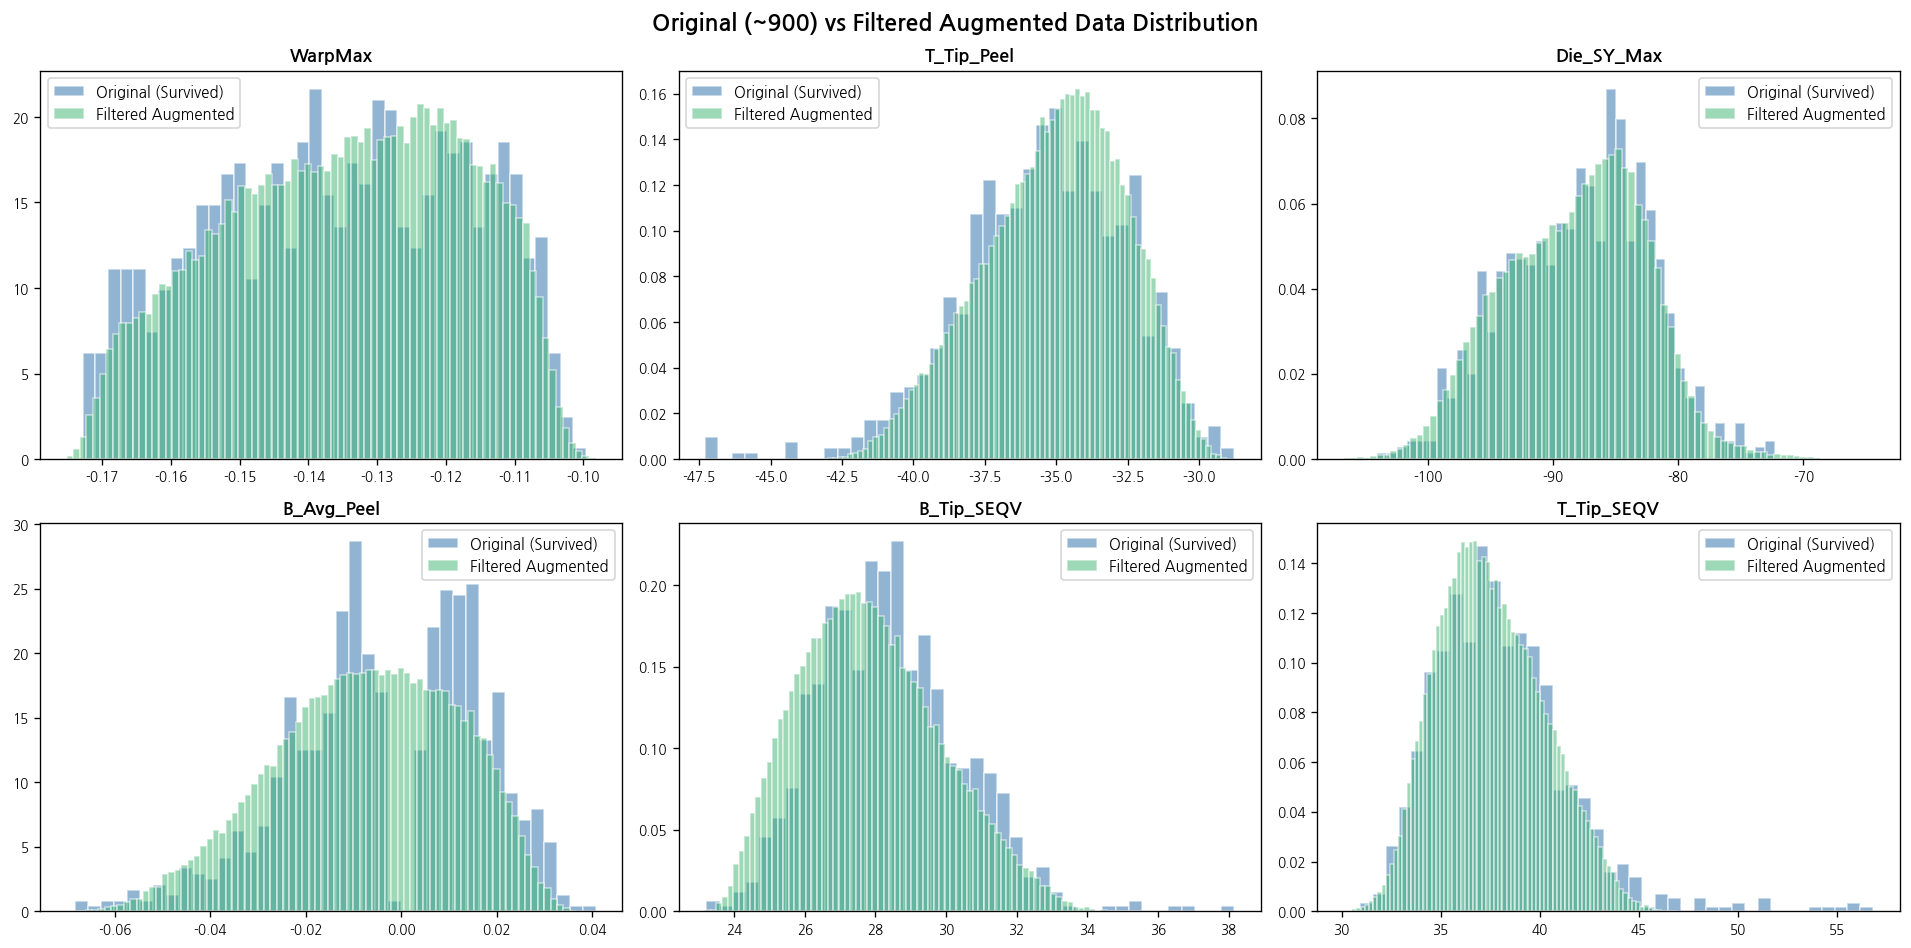

In [57]:
import time
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ====================================================================
# [6. 원본 데이터(df_peaks) 즉석 추출 로직 - 수정판]
# ====================================================================
valid_data = []     # 정상 추출된 데이터를 누적할 리스트
error_rows = []     # 읽기 오류가 발생한 Row_ID를 기록할 리스트

t_start = time.time()
print(f'\n{len(survived_ids)}개 생존 CSV에서 Max Peak 추출 시작 (시각화 비교용)...')

for i, row_id in enumerate(survived_ids):
    # 시계열 CSV 파일 경로 구성
    fpath = os.path.join(CSV_FOLDER, f'ML_DATA_Extract_Row_{row_id}.csv')
    
    try:
        # 시계열 데이터 로드 
        df_ts = pd.read_csv(fpath)
        df_ts.columns = [c.strip() for c in df_ts.columns]
        
        # 결과 딕셔너리 초기화
        peak_dict = {'Row_ID': row_id}
        
        # 마스터 DOE에서 해당 Row의 P1~P6 가져오기 (인덱스 기반 매칭)
        # Row_ID 1 = 인덱스 0
        idx = row_id - 1 
        for p_col in ['P1','P2','P3','P4','P5','P6']:
            peak_dict[p_col] = df_master.loc[idx, p_col]
        
        # === 핵심 로직: 각 Y 채널별 '절댓값 최대 피크(부호 유지)' 추출 ===
        for y_col in Y_COLUMNS:
            if y_col in df_ts.columns:
                max_abs_idx = df_ts[y_col].abs().idxmax()
                peak_dict[y_col] = df_ts.loc[max_abs_idx, y_col]
            else:
                peak_dict[y_col] = np.nan
        
        valid_data.append(peak_dict)
        
    except Exception as e:
        error_rows.append((row_id, str(e)))

elapsed = time.time() - t_start

# 결과 취합
df_peaks = pd.DataFrame(valid_data)

print(f'\n=== Max Peak 추출 완료 ===')
print(f'성공: {len(df_peaks)}개 / 실패: {len(error_rows)}개 / 소요시간: {elapsed:.1f}초')

# 방어 코드: 추출 성공 데이터가 없을 경우 에러 방지
if df_peaks.empty:
    raise ValueError("추출된 데이터가 0개입니다. 경로 설정이나 마스터 파일 인덱스를 확인하세요.")

# NaN이 있는 행 확인 및 제거
nan_count = df_peaks[Y_COLUMNS].isnull().any(axis=1).sum()
if nan_count > 0:
    print(f'[경고] {nan_count}개 행에 NaN 존재 -> 해당 행 제거')
    df_peaks = df_peaks.dropna(subset=Y_COLUMNS).reset_index(drop=True)

# ====================================================================
# [7. 원본 vs Gatekeeper 필터링 완료 증강 데이터 분포 시각화]
# ====================================================================
# Step 2에서 방금 저장한 '분류 이후의 안전한 데이터셋' 로드
filtered_csv_path = 'Augmented_Class_Data.csv'
df_augmented_filtered = pd.read_csv(filtered_csv_path)

# 시각화할 6대 핵심 채널 (노이즈 배제)
check_cols = ['WarpMax', 'T_Tip_Peel', 'Die_SY_Max', 
              'B_Avg_Peel', 'B_Tip_SEQV', 'T_Tip_SEQV']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Original (~900) vs Filtered Augmented Data Distribution',
             fontsize=14, fontweight='bold')

for idx, y_col in enumerate(check_cols):
    ax = axes[idx // 3, idx % 3]
    
    # 원본 데이터 분포 (파란색 히스토그램)
    ax.hist(df_peaks[y_col], bins=40, density=True, alpha=0.6,
            color='steelblue', edgecolor='white', label='Original (Survived)')
    
    # Gatekeeper를 통과한 고품질 증강 데이터 분포 (녹색 히스토그램)
    ax.hist(df_augmented_filtered[y_col], bins=80, density=True, alpha=0.5,
            color='mediumseagreen', edgecolor='white', label='Filtered Augmented')
    
    ax.set_title(y_col, fontweight='bold', fontsize=11)
    ax.legend(fontsize=9)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()


# [Step 3] 파레토 프론티어(Pareto Frontier) 타겟 곡선 추출

## 목표
역설계 AI(Step 4)에 입력할 **'물리적으로 도달 가능하면서도 이상적인 타겟 시계열 텐서'**를 생성한다.

## 파레토 비지배 정렬 (Non-dominated Sorting)
원본 생존 데이터(~900개)에서 **WarpMax**와 **T_Tip_Peel** 단 2개 변수의 절댓값을 기준으로
파레토 최적 DP(Frontier 0)를 선별한다.
```
판정 기준: 두 목적함수 모두 최소화
  - obj1 = |WarpMax|   → 패키지 휨 최소화
  - obj2 = |T_Tip_Peel| → 계면 박리 응력 최소화

비지배 조건:
  DP_j가 DP_i를 "지배"한다 = j가 모든 목적에서 i 이하이고, 최소 하나에서 엄격히 작다
  → 아무에게도 지배당하지 않는 DP만 파레토 Frontier 0으로 선정
```

## 핵심 채널 선정 (7채널)
GPR ARD 커널의 학습 결과(R² 기준)로 확정된 **신뢰 가능한 7개 채널**만 사용한다.
R²가 낮은 변수(T_Tip_Shear, T_Avg_Peel 등)는 예측 신뢰도가 부족하여 제외.
```
채널                GPR Test R²    역할
─────────────────────────────────────────────
WarpMax             0.999          최소화 메인 타겟 #1
T_Tip_Peel          0.773          최소화 메인 타겟 #2
Die_SY_Max          0.900          다이 모서리 응력 (Hard Constraint)
B_Avg_Peel          0.844          Bottom 평균 박리 (Hard Constraint)
B_Tip_SEQV          0.829          Bottom 끝단 등가응력 (Hard Constraint)
T_Tip_Strain        0.798          Top 끝단 변형률 (Hard Constraint)
T_Tip_SEQV          0.588          Top 끝단 등가응력 (경계선, 주의 필요)
```

## 유토피아 타겟 텐서 생성
```
파레토 Frontier 0 DP 선별
    ↓ 해당 Row_ID의 원본 시계열 CSV 호출 (617 timestep × 17열)
    ↓ 7대 핵심 채널만 추출
    ↓ 전 채널에 동일 스칼라(×0.9) 곱셈 → 진폭 10% 하향
    ↓ 물리적 위상차·파형 형태 100% 보존
Utopia_Target_Row_{Row_ID}.csv 저장 → Step 4로 전달
```

### ×0.9 스케일링의 물리적 의미
- 현재 파레토 1등의 곡선 형태(가열-유지-냉각 위상)는 그대로 유지
- 진폭만 10% 낮춰 **"현실에 가깝지만 약간 더 나은"** 유토피아 목표 설정
- 비현실적으로 낮은 목표(×0.5 등)는 AI가 물리적으로 불가능한 설계를 출력할 위험

## 출력
- `Utopia_Target_Tensors/Utopia_Target_Row_{ID}.csv`: 파레토 DP별 7채널 × 617 timestep
- 용도: Step 4 역설계 모델(1D-CNN)의 입력 텐서

In [58]:
# ====================================================================
# [1. 환경 및 타겟 설정]
# ====================================================================
CORE_7_CHANNELS = [
    'WarpMax', 'Die_SY_Max', 'B_Avg_Peel', 'B_Tip_SEQV', 
    'T_Tip_Strain', 'T_Tip_Peel', 'T_Tip_SEQV'
]

UTOPIA_RATIO = 0.90 
TENSOR_DIR = os.path.join(BASE_DIR, 'Utopia_Target_Tensors')  # 절대 경로 통일
os.makedirs(TENSOR_DIR, exist_ok=True)

print("=== [Step 3] 파레토 비지배 정렬 및 유토피아 타겟 추출 ===")

# ====================================================================
# [2. 다단계 Pareto Non-dominated Sorting (Frontier 0 + 1 + ...)]
# ====================================================================
obj1 = df_peaks['WarpMax'].abs().values
obj2 = df_peaks['T_Tip_Peel'].abs().values
scores = np.column_stack((obj1, obj2))

population_size = scores.shape[0]

# 다단계 비지배 정렬: Frontier 0, 1, 2, ... 순서로 계층 분류
# Frontier 0 = 최상위 (아무에게도 지배 안 당함)
# Frontier 1 = Frontier 0 제거 후 비지배 해
# ...반복
frontier_labels = np.full(population_size, -1, dtype=int)  # 각 DP의 Frontier 등급
remaining = np.ones(population_size, dtype=bool)             # 아직 분류 안 된 DP
frontier_level = 0

while remaining.any():
    remaining_idx = np.where(remaining)[0]
    current_scores = scores[remaining_idx]
    is_pareto = np.ones(len(remaining_idx), dtype=bool)
    
    for i in range(len(remaining_idx)):
        for j in range(len(remaining_idx)):
            if i == j:
                continue
            # j가 i를 지배하는지 판정
            if all(current_scores[j] <= current_scores[i]) and any(current_scores[j] < current_scores[i]):
                is_pareto[i] = False
                break
    
    # 현재 Frontier에 해당하는 DP에 등급 부여
    for k, idx in enumerate(remaining_idx):
        if is_pareto[k]:
            frontier_labels[idx] = frontier_level
            remaining[idx] = False
    
    print(f'  Frontier {frontier_level}: {is_pareto.sum()}개')
    frontier_level += 1
    
    # 안전 장치: 최대 10단계까지만
    if frontier_level >= 10:
        break

# Frontier 등급을 df_peaks에 추가
df_peaks['frontier'] = frontier_labels

# === 파레토 상위 N% 또는 최소 수량 확보 ===
MIN_PARETO_COUNT = 30  # 최소 확보 목표 (Step 4 학습에 필요한 하한)

# Frontier 0부터 순서대로 누적하여 최소 수량 충족될 때까지 확장
selected_frontiers = []
cumulative = 0
for level in range(frontier_level):
    count_at_level = (frontier_labels == level).sum()
    selected_frontiers.append(level)
    cumulative += count_at_level
    if cumulative >= MIN_PARETO_COUNT:
        break

df_pareto = df_peaks[df_peaks['frontier'].isin(selected_frontiers)].copy()
num_pareto = len(df_pareto)
max_frontier = max(selected_frontiers)

print(f'\n총 {population_size}개 중 파레토 Frontier 0~{max_frontier}: {num_pareto}개 ({num_pareto/population_size*100:.1f}%)')
print(f'  (Frontier 0만: {(frontier_labels==0).sum()}개 → 부족하여 Frontier {max_frontier}까지 확장)')

if num_pareto < MIN_PARETO_COUNT:
    print(f'[경고] {num_pareto}개로 목표({MIN_PARETO_COUNT})에 미달. 가용 데이터 전부 사용.')

=== [Step 3] 파레토 비지배 정렬 및 유토피아 타겟 추출 ===
  Frontier 0: 8개
  Frontier 1: 8개
  Frontier 2: 12개
  Frontier 3: 12개
  Frontier 4: 16개
  Frontier 5: 18개
  Frontier 6: 20개
  Frontier 7: 23개
  Frontier 8: 20개
  Frontier 9: 35개

총 884개 중 파레토 Frontier 0~3: 40개 (4.5%)
  (Frontier 0만: 8개 → 부족하여 Frontier 3까지 확장)


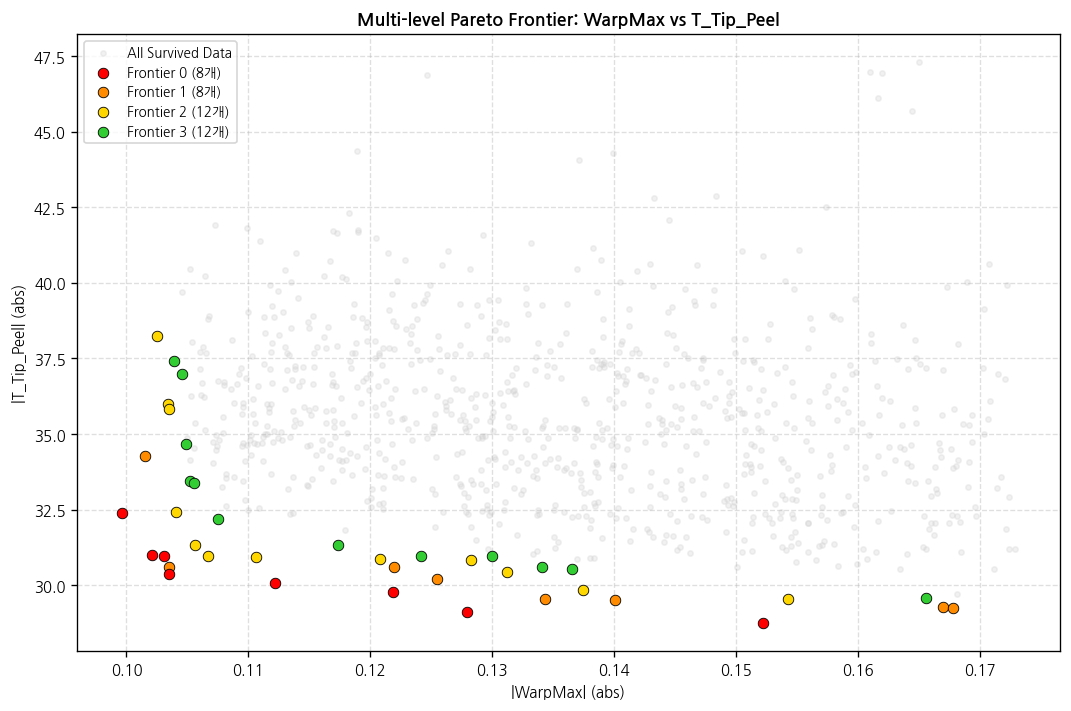

→ 빨간색(Frontier 0)에 가까울수록 WarpMax와 T_Tip_Peel이 동시에 작은 우수 설계
→ 총 40개의 유토피아 타겟 텐서가 Step 4로 전달됨


In [59]:
# ====================================================================
# [3. 다단계 파레토 프론티어 시각화]
# ====================================================================
plt.figure(figsize=(9, 6))

# 전체 데이터 (회색 배경)
plt.scatter(obj1, obj2, color='lightgray', alpha=0.3, s=10, label='All Survived Data')

# Frontier 등급별 색상 구분
colors = ['red', 'darkorange', 'gold', 'limegreen', 'deepskyblue']
for level in selected_frontiers:
    mask = frontier_labels == level
    n = mask.sum()
    c = colors[level] if level < len(colors) else 'gray'
    plt.scatter(obj1[mask], obj2[mask], color=c, s=40, edgecolors='black',
                linewidths=0.5, label=f'Frontier {level} ({n}개)', zorder=5-level)

plt.title('Multi-level Pareto Frontier: WarpMax vs T_Tip_Peel', fontweight='bold')
plt.xlabel('|WarpMax| (abs)')
plt.ylabel('|T_Tip_Peel| (abs)')
plt.legend(fontsize=8)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f'→ 빨간색(Frontier 0)에 가까울수록 WarpMax와 T_Tip_Peel이 동시에 작은 우수 설계')
print(f'→ 총 {num_pareto}개의 유토피아 타겟 텐서가 Step 4로 전달됨')

In [60]:
# ====================================================================
# [4. 시계열 원본 호출 및 7채널 유토피아 텐서 변환/저장]
# ====================================================================
print(f"\n파레토 상위 데이터({num_pareto}개)의 시계열 원본을 7채널 유토피아 텐서로 변환합니다...")

# Step 4에서 사용하는 공통 시간축과 동일하게 리샘플링
TARGET_LEN = 600
t_common = np.linspace(0, 300, TARGET_LEN)

utopia_files = []

for idx, row in df_pareto.iterrows():
    row_id = int(row['Row_ID'])
    csv_path = os.path.join(CSV_FOLDER, f'ML_DATA_Extract_Row_{row_id}.csv')
    
    try:
        df_ts = pd.read_csv(csv_path)
        df_ts.columns = [c.strip() for c in df_ts.columns]
        
        # 원본 시간축
        t_original = df_ts['Time'].values
        
        # 7채널을 공통 시간축(600포인트)으로 선형 보간
        ts_resampled = {}
        for col in CORE_7_CHANNELS:
            ts_resampled[col] = np.interp(t_common, t_original, df_ts[col].values)
        
        df_7ch = pd.DataFrame(ts_resampled)
        
        # 유토피아 스케일링: 진폭을 10% 깎음 (위상차·파형 100% 보존)
        df_utopia = df_7ch * UTOPIA_RATIO
        
        # 저장
        save_name = f'Utopia_Target_Row_{row_id}.csv'
        save_path = os.path.join(TENSOR_DIR, save_name)
        df_utopia.to_csv(save_path, index=False)
        utopia_files.append(save_name)
        
    except Exception as e:
        print(f"[오류] Row_ID {row_id}: {e}")

print(f"\n유토피아 타겟 텐서 생성 완료! ({len(utopia_files)}개 저장)")
print(f"저장 폴더: {TENSOR_DIR}")
print(f"각 파일: {TARGET_LEN} timestep × {len(CORE_7_CHANNELS)} channels (리샘플링 + ×{UTOPIA_RATIO})")
print("→ [Step 4: 오토인코더 역설계]의 입력 텐서로 사용됩니다.")


파레토 상위 데이터(40개)의 시계열 원본을 7채널 유토피아 텐서로 변환합니다...

유토피아 타겟 텐서 생성 완료! (40개 저장)
저장 폴더: /mnt/i/ai_model_dev/cfd/Utopia_Target_Tensors
각 파일: 600 timestep × 7 channels (리샘플링 + ×0.9)
→ [Step 4: 오토인코더 역설계]의 입력 텐서로 사용됩니다.


================================================================================
# [Step 4] 딥러닝 기반 역설계 — 오토인코더 잠재 매핑 (Autoencoder Latent Mapping)
================================================================================

## 목표
Step 3에서 생성된 유토피아 타겟 텐서(7채널 × 617 timestep)를 입력하면,
이를 구현할 수 있는 **최적의 P1~P6 설계변수 초안**을 출력한다.

## 전략: 2단계 잠재 공간 매핑
고차원 시계열(617×7 = 4,319차원)을 직접 역매핑하면 일대다(one-to-many) 문제로
수렴이 불안정하다. 대신 오토인코더로 **잠재 공간(32차원)**에 압축한 뒤,
저차원에서 P↔z 매핑을 학습하여 안정적인 역설계를 수행한다.

## 파이프라인 흐름

    [Step 4-1] 시계열 오토인코더 학습 (비지도, 원본 ~900개 전부 사용)
        입력: 원본 시계열 (617 × 7ch)
          ↓ Encoder (1D-CNN): 시계열 → 잠재 벡터 z (32차원)
          ↓ Decoder (1D-ConvTranspose): z → 시계열 복원
          ↓ 복원 오차(MSE) 최소화
        결과: Encoder/Decoder 확보

    [Step 4-2] 잠재 공간 매핑 학습 (지도, ~900개)
        순방향: P1~P6 → z  (MLP)
        역방향: z → P1~P6  (MLP)

    [Step 4-3] 유토피아 타겟 역설계 (추론)
        유토피아 텐서 → Encoder → z_target → 역매핑 MLP → P1~P6 초안
        → Step 5 GA 미세조정의 시작점(±10%)으로 전달

## 출력
    - P1~P6 초안 (파레토 DP별)
    - Inverse_Design_Results.csv → Step 5로 전달

In [61]:
TENSOR_DIR = os.path.join(BASE_DIR, 'Utopia_Target_Tensors')

# Step 3에서 확정된 7대 핵심 채널 (GPR ARD R² 기준 신뢰 가능 채널)
CORE_7_CHANNELS = [
    'WarpMax', 'Die_SY_Max', 'B_Avg_Peel', 'B_Tip_SEQV',
    'T_Tip_Strain', 'T_Tip_Peel', 'T_Tip_SEQV'
]

N_CHANNELS  = len(CORE_7_CHANNELS)   # 7
LATENT_DIM  = 32                      # 잠재 공간 차원 수
SEED        = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

print(f'=== [Step 4] 오토인코더 잠재 매핑 역설계 ===')
print(f'디바이스    : {device}')
print(f'핵심 채널   : {N_CHANNELS}개 {CORE_7_CHANNELS}')
print(f'잠재 차원   : {LATENT_DIM}')
print(f'텐서 폴더   : {TENSOR_DIR}')

=== [Step 4] 오토인코더 잠재 매핑 역설계 ===
디바이스    : cuda
핵심 채널   : 7개 ['WarpMax', 'Die_SY_Max', 'B_Avg_Peel', 'B_Tip_SEQV', 'T_Tip_Strain', 'T_Tip_Peel', 'T_Tip_SEQV']
잠재 차원   : 32
텐서 폴더   : /mnt/i/ai_model_dev/cfd/Utopia_Target_Tensors


In [63]:
# 디버깅용: 각 파일의 행 수 분포 확인
from collections import Counter
row_counts = []
for row_id in sorted(survived_ids)[:50]:  # set → sorted list로 변환 후 슬라이싱
    fpath = os.path.join(CSV_FOLDER, f'ML_DATA_Extract_Row_{row_id}.csv')
    df_tmp = pd.read_csv(fpath)
    row_counts.append(len(df_tmp))
print(Counter(row_counts))

Counter({612: 29, 614: 5, 615: 3, 616: 3, 617: 2, 613: 2, 618: 1, 631: 1, 623: 1, 620: 1, 621: 1, 619: 1})


In [88]:
# ====================================================================
# [1. 원본 시계열 데이터 로드 (학습용)]
# ====================================================================
# 원본 ~900개의 생존 CSV에서 7채널 시계열을 텐서로 변환
# 오토인코더는 비지도 학습이므로 P1~P6 라벨 없이 시계열만 필요
# (단, 4-2에서 P↔z 매핑 학습 시 P1~P6도 사용)

print('\n[1] 원본 시계열 로드 중...')

# Run All 안전장치: df_master에 Row_ID가 없으면 재추가
# (Step 1에서 추가했더라도 이 셀에서 재로드되었을 수 있음)
if 'Row_ID' not in df_master.columns:
    df_master.insert(0, 'Row_ID', range(1, len(df_master) + 1))
    print('  Row_ID 컬럼 재추가 완료')

# Run All 안전장치: survived_ids가 set이면 sorted list로 변환
if isinstance(survived_ids, set):
    survived_ids = sorted(survived_ids)
    print('  survived_ids: set → sorted list 변환 완료')

# 시계열 텐서 + P1~P6 동시 수집
all_timeseries = []   # shape: (N, TARGET_LEN, 7)
all_params = []       # shape: (N, 6)
valid_row_ids = []

# 공통 타임스텝 수 설정 (모든 시계열을 이 길이로 리샘플링)
TARGET_LEN = 600  # 가장 짧은 파일(612)보다 약간 작게 설정하여 안전 마진 확보

# 공통 시간축 (0~300초를 TARGET_LEN개로 균등 분할)
t_common = np.linspace(0, 300, TARGET_LEN)

for row_id in survived_ids:
    fpath = os.path.join(CSV_FOLDER, f'ML_DATA_Extract_Row_{row_id}.csv')
    master_row = df_master[df_master['Row_ID'] == row_id]
    if master_row.empty:
        continue

    try:
        df_ts = pd.read_csv(fpath)
        df_ts.columns = [c.strip() for c in df_ts.columns]

        # 원본 시간축 추출
        t_original = df_ts['Time'].values

        # 7채널을 공통 시간축으로 선형 보간
        ts_resampled = np.zeros((TARGET_LEN, N_CHANNELS))
        for ch, col in enumerate(CORE_7_CHANNELS):
            ts_resampled[:, ch] = np.interp(t_common, t_original, df_ts[col].values)

        from scipy.signal import savgol_filter

# ... (기존 코드: 시계열 로드, 보간까지 동일) ...

        # 7채널을 공통 시간축으로 선형 보간
        ts_resampled = np.zeros((TARGET_LEN, N_CHANNELS))
        for ch, col in enumerate(CORE_7_CHANNELS):
            ts_resampled[:, ch] = np.interp(t_common, t_original, df_ts[col].values)

        # ── 사비츠키-골레이 필터로 노이즈 제거 ──
        # window_length=11: 약 5.5초 구간 (300초/600포인트 = 0.5초 간격 × 11)
        #   → 스텝 경계(수십 초 단위 전이)보다 충분히 짧아 경계 보존
        #   → 고주파 시뮬레이션 노이즈(메쉬 진동 등)만 제거
        # polyorder=3: 3차 다항식 피팅
        #   → 2차는 곡률 손실, 4차 이상은 노이즈 잔존 → 3차가 최적
        for ch in range(N_CHANNELS):
            ts_resampled[:, ch] = savgol_filter(
                ts_resampled[:, ch],
                window_length=11,   # 홀수, 작을수록 경계 보존 ↑ 노이즈 제거 ↓
                polyorder=3
            )

        # NaN이나 Inf 체크
        if np.isnan(ts_resampled).any() or np.isinf(ts_resampled).any():
            continue

        all_timeseries.append(ts_resampled)
        all_params.append(master_row[['P1','P2','P3','P4','P5','P6']].values[0])
        valid_row_ids.append(row_id)

    except Exception as e:
        pass

# numpy 배열로 변환 (이제 모든 시계열이 동일 길이)
X_ts = np.array(all_timeseries, dtype=np.float32)   # (N, 600, 7)
X_params = np.array(all_params, dtype=np.float32)    # (N, 6)

N_SAMPLES, N_TIMESTEPS, _ = X_ts.shape

print(f'로드 완료: {N_SAMPLES}개 시계열')
print(f'시계열 shape: {X_ts.shape} → (샘플, 타임스텝, 채널)')
print(f'P1~P6 shape : {X_params.shape}')
print(f'공통 시간축: 0~300초, {TARGET_LEN}포인트 (선형 보간)')


[1] 원본 시계열 로드 중...
로드 완료: 884개 시계열
시계열 shape: (884, 600, 7) → (샘플, 타임스텝, 채널)
P1~P6 shape : (884, 6)
공통 시간축: 0~300초, 600포인트 (선형 보간)


In [89]:
# ====================================================================
# [2. 데이터 전처리 (채널별 StandardScaler)]
# ====================================================================
# 오토인코더 학습 전 각 채널을 독립적으로 정규화
# 채널별 스케일 차이가 크므로 (WarpMax: ~0.1, T_Tip_SEQV: ~40) 필수

print('\n[2] 채널별 StandardScaler 적용...')

# 채널별 scaler 저장 (추론 시 역변환에 필요)
channel_scalers = []
X_ts_scaled = np.zeros_like(X_ts)

for ch in range(N_CHANNELS):
    scaler = StandardScaler()
    # (N, 617) → fit_transform → (N, 617)
    ch_data = X_ts[:, :, ch]                        # 모든 샘플의 ch번째 채널
    X_ts_scaled[:, :, ch] = scaler.fit_transform(ch_data)
    channel_scalers.append(scaler)
    print(f'  {CORE_7_CHANNELS[ch]:15s} | mean={scaler.mean_[0]:.4f}, std={scaler.scale_[0]:.4f}')

# P1~P6도 정규화 (Step 4-2에서 사용)
param_scaler = StandardScaler()
X_params_scaled = param_scaler.fit_transform(X_params)

# PyTorch 텐서로 변환
# Conv1d는 (batch, channels, length) 형태를 기대하므로 transpose
X_tensor = torch.FloatTensor(X_ts_scaled).permute(0, 2, 1)  # (N, 7, 617)
P_tensor = torch.FloatTensor(X_params_scaled)                 # (N, 6)

print(f'\nPyTorch 텐서 shape: X={X_tensor.shape}, P={P_tensor.shape}')


[2] 채널별 StandardScaler 적용...
  WarpMax         | mean=-0.1064, std=0.0106
  T_Tip_Peel      | mean=-34.3037, std=2.6097
  Die_SY_Max      | mean=-85.5312, std=5.4736
  B_Avg_Peel      | mean=-0.0028, std=0.0182
  B_Tip_SEQV      | mean=27.4355, std=1.9551
  T_Tip_Strain    | mean=0.0020, std=0.0001
  T_Tip_SEQV      | mean=36.9350, std=2.6847

PyTorch 텐서 shape: X=torch.Size([884, 7, 600]), P=torch.Size([884, 6])


In [128]:
# ====================================================================
# [3. 오토인코더 모델 정의]
# ====================================================================
# Encoder: 1D-CNN으로 시계열을 잠재 벡터로 압축
# Decoder: Upsample + Conv1d로 복원 (ConvTranspose의 체커보드 아티팩트 해소)

# ====================================================================
# [3. 오토인코더 모델 정의 (Zero-Padding 제거 버전)]
# ====================================================================
class Encoder(nn.Module):
    def __init__(self, n_channels=7, latent_dim=64): # 잠재 차원 기본값 확장
        super().__init__()
        self.conv_blocks = nn.Sequential(
            nn.Conv1d(n_channels, 32, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.1),

            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),

            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1),
        )
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(128, latent_dim)

    def forward(self, x):
        h = self.conv_blocks(x)
        h = self.global_pool(h)
        h = h.squeeze(-1)
        z = self.fc(h)
        return z

class Decoder(nn.Module):
    def __init__(self, n_channels=7, latent_dim=64): # 잠재 차원 기본값 확장
        super().__init__()
        self.fc = nn.Linear(latent_dim, 128 * 75)

        # padding_mode='replicate' 적용: 엣지(Edge) 추락 아티팩트 완벽 방어
        self.up_blocks = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv1d(128, 64, kernel_size=5, stride=1, padding=2, padding_mode='replicate'),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),

            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv1d(64, 32, kernel_size=5, stride=1, padding=2, padding_mode='replicate'),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.1),

            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv1d(32, n_channels, kernel_size=7, stride=1, padding=3, padding_mode='replicate'),
        )

    def forward(self, z):
        h = self.fc(z)
        h = h.view(-1, 128, 75)
        h = self.up_blocks(h)
        h = torch.nn.functional.interpolate(h, size=600, mode='linear', align_corners=False)
        return h

class TimeSeriesAutoencoder(nn.Module):
    def __init__(self, n_channels=7, latent_dim=64):
        super().__init__()
        self.encoder = Encoder(n_channels, latent_dim)
        self.decoder = Decoder(n_channels, latent_dim)

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon, z

# 잠재 공간을 32 -> 64로 2배 확장하여 정보 병목(언더피팅) 해소
LATENT_DIM = 64  

print('[3] 오토인코더 모델 구조 (Replicate Padding 적용):')
ae_model = TimeSeriesAutoencoder(N_CHANNELS, LATENT_DIM).to(device)
total_params = sum(p.numel() for p in ae_model.parameters())
print(f'  총 파라미터: {total_params:,}개')
print(f'  Encoder: (batch, {N_CHANNELS}, {N_TIMESTEPS}) → (batch, {LATENT_DIM})')
print(f'  Decoder: (batch, {LATENT_DIM}) → (batch, {N_CHANNELS}, {N_TIMESTEPS})')

[3] 오토인코더 모델 구조 (Replicate Padding 적용):
  총 파라미터: 738,759개
  Encoder: (batch, 7, 600) → (batch, 64)
  Decoder: (batch, 64) → (batch, 7, 600)


In [129]:
# ====================================================================
# [4. 오토인코더 학습 (비지도)]
# ====================================================================
# 원본 ~900개 시계열의 복원 오차(MSE)를 최소화
# 라벨(P1~P6)이 필요 없으므로 전체 데이터를 비지도로 학습

AE_EPOCHS     = 400       # 에포크 수
AE_BATCH_SIZE = 32        # 배치 크기
AE_LR         = 1e-3      # 학습률
AE_PATIENCE   = 40       # Early Stopping 인내심

print(f'\n[4] 오토인코더 학습 시작 (epochs={AE_EPOCHS}, batch={AE_BATCH_SIZE}, lr={AE_LR})')

# Train/Val 분리 (85:15)
n_train = int(N_SAMPLES * 0.85)
indices = np.random.permutation(N_SAMPLES)
train_idx, val_idx = indices[:n_train], indices[n_train:]

train_loader = DataLoader(
    TensorDataset(X_tensor[train_idx]),
    batch_size=AE_BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(X_tensor[val_idx]),
    batch_size=AE_BATCH_SIZE, shuffle=False
)

# 옵티마이저 및 스케줄러
optimizer_ae = optim.Adam(ae_model.parameters(), lr=AE_LR, weight_decay=1e-5)
scheduler_ae = optim.lr_scheduler.ReduceLROnPlateau(optimizer_ae, patience=10, factor=0.5)
criterion_ae = nn.MSELoss()

# 학습 루프
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0

t_start = time.time()

for epoch in range(AE_EPOCHS):
    # -- Train --
    ae_model.train()
    epoch_train_loss = 0
    for (batch_x,) in train_loader:
        batch_x = batch_x.to(device)
        x_recon, z = ae_model(batch_x)
        loss = criterion_ae(x_recon, batch_x)
        optimizer_ae.zero_grad()
        loss.backward()
        optimizer_ae.step()
        epoch_train_loss += loss.item() * len(batch_x)
    epoch_train_loss /= n_train

    # -- Validation --
    ae_model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for (batch_x,) in val_loader:
            batch_x = batch_x.to(device)
            x_recon, z = ae_model(batch_x)
            loss = criterion_ae(x_recon, batch_x)
            epoch_val_loss += loss.item() * len(batch_x)
    epoch_val_loss /= (N_SAMPLES - n_train)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    scheduler_ae.step(epoch_val_loss)

    # Early Stopping 체크
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        # 베스트 모델 저장
        best_ae_state = ae_model.state_dict().copy()
    else:
        patience_counter += 1

    # 진행 출력 (20에포크마다)
    if (epoch + 1) % 20 == 0:
        lr_now = optimizer_ae.param_groups[0]['lr']
        print(f'  Epoch {epoch+1:3d}/{AE_EPOCHS} | '
              f'Train Loss: {epoch_train_loss:.6f} | Val Loss: {epoch_val_loss:.6f} | '
              f'LR: {lr_now:.2e} | Patience: {patience_counter}/{AE_PATIENCE}')

    if patience_counter >= AE_PATIENCE:
        print(f'  → Early Stopping at epoch {epoch+1}')
        break

# 베스트 모델 복원
ae_model.load_state_dict(best_ae_state)
elapsed = time.time() - t_start
print(f'\n오토인코더 학습 완료 ({elapsed:.1f}초)')
print(f'최종 Val Loss: {best_val_loss:.6f}')


[4] 오토인코더 학습 시작 (epochs=400, batch=32, lr=0.001)
  Epoch  20/400 | Train Loss: 0.133228 | Val Loss: 0.114855 | LR: 1.00e-03 | Patience: 1/40
  Epoch  40/400 | Train Loss: 0.115730 | Val Loss: 0.092791 | LR: 1.00e-03 | Patience: 3/40
  Epoch  60/400 | Train Loss: 0.090282 | Val Loss: 0.071297 | LR: 5.00e-04 | Patience: 0/40
  Epoch  80/400 | Train Loss: 0.073823 | Val Loss: 0.068429 | LR: 2.50e-04 | Patience: 0/40
  Epoch 100/400 | Train Loss: 0.067311 | Val Loss: 0.070935 | LR: 1.25e-04 | Patience: 20/40
  Epoch 120/400 | Train Loss: 0.066932 | Val Loss: 0.069920 | LR: 6.25e-05 | Patience: 18/40
  Epoch 140/400 | Train Loss: 0.062537 | Val Loss: 0.070851 | LR: 1.56e-05 | Patience: 38/40
  → Early Stopping at epoch 142

오토인코더 학습 완료 (11.2초)
최종 Val Loss: 0.068418


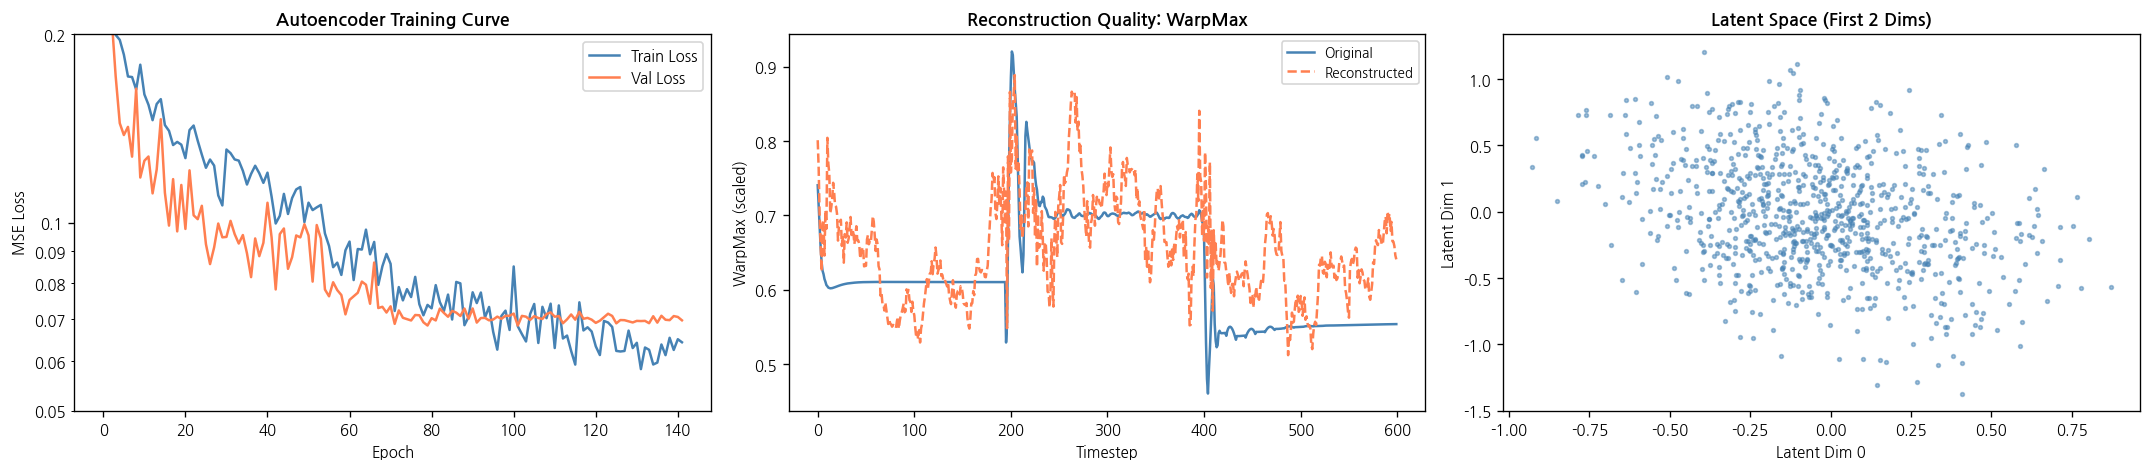

In [149]:
# ====================================================================
# [5. 오토인코더 학습 결과 시각화]
# ====================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# --- (A) 학습 곡선 ---
ax = axes[0]
ax.plot(train_losses, label='Train Loss', color='steelblue')
ax.plot(val_losses, label='Val Loss', color='coral')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Autoencoder Training Curve', fontweight='bold')
ax.legend()
ax.set_yscale('log')

# [추가/수정 1] 지수 표기(10^-1)를 소수점(0.1, 0.01)으로 강제 포맷팅
formatter = ticker.FuncFormatter(lambda y, _: '{:g}'.format(y))
ax.yaxis.set_major_formatter(formatter)
ax.yaxis.set_minor_formatter(formatter)

# [추가/수정 2] Y축 범위를 0.05 ~ 0.20 내외로 고정하여 수렴 구간 집중 확대
# (데이터의 시작점과 수렴점이 잘 보이도록 상하단을 조율했습니다. 필요시 숫자 변경 가능)
ax.set_ylim(0.05, 0.20)

# --- (B) 복원 품질 예시 (검증 샘플 중 무작위 1개 선택) ---
ax = axes[1]
ae_model.eval()
with torch.no_grad():
    # val_idx 중에서 무작위 인덱스 하나를 뽑음
    rand_idx = np.random.randint(0, len(val_idx))
    sample_x = X_tensor[val_idx[rand_idx]:val_idx[rand_idx]+1].to(device)
    sample_recon, _ = ae_model(sample_x)
    
    sample_x_np = sample_x.cpu().numpy()[0]           # (7, 617)
    sample_recon_np = sample_recon.cpu().numpy()[0]    # (7, 617)

# WarpMax 채널 (index 0) 비교
ch_idx = 0
ax.plot(sample_x_np[ch_idx], label='Original', color='steelblue', linewidth=1.5)
ax.plot(sample_recon_np[ch_idx], label='Reconstructed', color='coral', linewidth=1.5, linestyle='--')
ax.set_xlabel('Timestep')
ax.set_ylabel(f'{CORE_7_CHANNELS[ch_idx]} (scaled)')
ax.set_title(f'Reconstruction Quality: {CORE_7_CHANNELS[ch_idx]}', fontweight='bold')
ax.legend(fontsize=8)

# --- (C) 잠재 공간 2D 시각화 (t-SNE 대신 첫 2차원 사용) ---
ax = axes[2]
ae_model.eval()
with torch.no_grad():
    all_z = ae_model.encoder(X_tensor.to(device)).cpu().numpy()  # (N, 32)
ax.scatter(all_z[:, 0], all_z[:, 1], s=5, alpha=0.5, c='steelblue')
ax.set_xlabel('Latent Dim 0')
ax.set_ylabel('Latent Dim 1')
ax.set_title('Latent Space (First 2 Dims)', fontweight='bold')

plt.tight_layout()
plt.show()

In [131]:
# ====================================================================
# [6. 잠재 벡터 추출 (전체 데이터)]
# ====================================================================
# 학습된 Encoder로 ~900개 전체의 잠재 벡터 z를 추출
# 이 z와 P1~P6의 쌍으로 Step 4-2 매핑을 학습

print('\n[6] 전체 데이터 잠재 벡터 추출...')
ae_model.eval()
with torch.no_grad():
    Z_all = ae_model.encoder(X_tensor.to(device)).cpu().numpy()  # (N, 32)

print(f'잠재 벡터 shape: {Z_all.shape} → (샘플, 잠재차원)')

# 잠재 벡터도 정규화 (MLP 매핑 학습 안정화)
z_scaler = StandardScaler()
Z_all_scaled = z_scaler.fit_transform(Z_all)


[6] 전체 데이터 잠재 벡터 추출...
잠재 벡터 shape: (884, 64) → (샘플, 잠재차원)


In [132]:
# ====================================================================
# [7. 역방향 매핑 MLP 정의 및 학습 (z → P1~P6)]
# ====================================================================
# 핵심: 잠재 벡터 z(32차원)로부터 설계변수 P1~P6(6차원)을 역추정
# 4,319차원(617×7) → 6차원 직접 매핑 대비 훨씬 안정적

class InverseMapper(nn.Module):
    """
    MLP 역매핑: 잠재 벡터 z (32차원) → P1~P6 (6차원)
    Dropout으로 과적합 방지, BatchNorm으로 학습 안정화
    """
    def __init__(self, latent_dim=32, output_dim=6):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.1),

            nn.Linear(32, output_dim),
        )

    def forward(self, z):
        return self.net(z)

# -- 모델 생성 --
inv_mapper = InverseMapper(LATENT_DIM, 6).to(device)
print(f'\n[7] 역매핑 MLP 파라미터: {sum(p.numel() for p in inv_mapper.parameters()):,}개')

# -- 학습 설정 --
INV_EPOCHS     = 300
INV_BATCH_SIZE = 32
INV_LR         = 1e-3
INV_PATIENCE   = 30

# Train/Val 분리 (동일 인덱스 사용)
Z_tensor = torch.FloatTensor(Z_all_scaled)

inv_train_loader = DataLoader(
    TensorDataset(Z_tensor[train_idx], P_tensor[train_idx]),
    batch_size=INV_BATCH_SIZE, shuffle=True
)
inv_val_loader = DataLoader(
    TensorDataset(Z_tensor[val_idx], P_tensor[val_idx]),
    batch_size=INV_BATCH_SIZE, shuffle=False
)

optimizer_inv = optim.Adam(inv_mapper.parameters(), lr=INV_LR, weight_decay=1e-5)
scheduler_inv = optim.lr_scheduler.ReduceLROnPlateau(optimizer_inv, patience=15, factor=0.5)
criterion_inv = nn.MSELoss()

# -- 학습 루프 --
print(f'역매핑 MLP 학습 시작 (epochs={INV_EPOCHS})')

inv_train_losses = []
inv_val_losses = []
best_inv_val_loss = float('inf')
inv_patience_counter = 0

t_start = time.time()

for epoch in range(INV_EPOCHS):
    # -- Train --
    inv_mapper.train()
    epoch_loss = 0
    for batch_z, batch_p in inv_train_loader:
        batch_z, batch_p = batch_z.to(device), batch_p.to(device)
        p_pred = inv_mapper(batch_z)
        loss = criterion_inv(p_pred, batch_p)
        optimizer_inv.zero_grad()
        loss.backward()
        optimizer_inv.step()
        epoch_loss += loss.item() * len(batch_z)
    epoch_loss /= n_train
    inv_train_losses.append(epoch_loss)

    # -- Validation --
    inv_mapper.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_z, batch_p in inv_val_loader:
            batch_z, batch_p = batch_z.to(device), batch_p.to(device)
            p_pred = inv_mapper(batch_z)
            loss = criterion_inv(p_pred, batch_p)
            val_loss += loss.item() * len(batch_z)
    val_loss /= (N_SAMPLES - n_train)
    inv_val_losses.append(val_loss)
    scheduler_inv.step(val_loss)

    # Early Stopping
    if val_loss < best_inv_val_loss:
        best_inv_val_loss = val_loss
        inv_patience_counter = 0
        best_inv_state = inv_mapper.state_dict().copy()
    else:
        inv_patience_counter += 1

    if (epoch + 1) % 30 == 0:
        print(f'  Epoch {epoch+1:3d}/{INV_EPOCHS} | '
              f'Train: {epoch_loss:.6f} | Val: {val_loss:.6f} | '
              f'Patience: {inv_patience_counter}/{INV_PATIENCE}')

    if inv_patience_counter >= INV_PATIENCE:
        print(f'  → Early Stopping at epoch {epoch+1}')
        break

inv_mapper.load_state_dict(best_inv_state)
elapsed = time.time() - t_start
print(f'\n역매핑 MLP 학습 완료 ({elapsed:.1f}초)')
print(f'최종 Val Loss: {best_inv_val_loss:.6f}')



[7] 역매핑 MLP 파라미터: 19,302개
역매핑 MLP 학습 시작 (epochs=300)
  Epoch  30/300 | Train: 0.150686 | Val: 0.111252 | Patience: 5/30
  Epoch  60/300 | Train: 0.129599 | Val: 0.106304 | Patience: 13/30
  Epoch  90/300 | Train: 0.119402 | Val: 0.102081 | Patience: 10/30
  Epoch 120/300 | Train: 0.116807 | Val: 0.102544 | Patience: 21/30
  → Early Stopping at epoch 129

역매핑 MLP 학습 완료 (5.9초)
최종 Val Loss: 0.098060



[8] 역매핑 성능 검증 (Validation Set)
   변수 |        MAE |       상대오차 |                 실제범위
-------------------------------------------------------
   P1 |     0.0203 |     2.17%  | [0.8012, 1.0988]
   P2 |     0.0019 |     2.89%  | [0.0500, 0.0897]
   P3 |     0.0088 |     1.35%  | [0.6002, 0.7192]
   P4 |     0.0132 |     7.21%  | [0.1016, 0.2828]
   P5 |     0.0197 |     1.33%  | [1.2016, 1.7935]
   P6 |     0.0040 |     6.62%  | [0.0403, 0.0798]


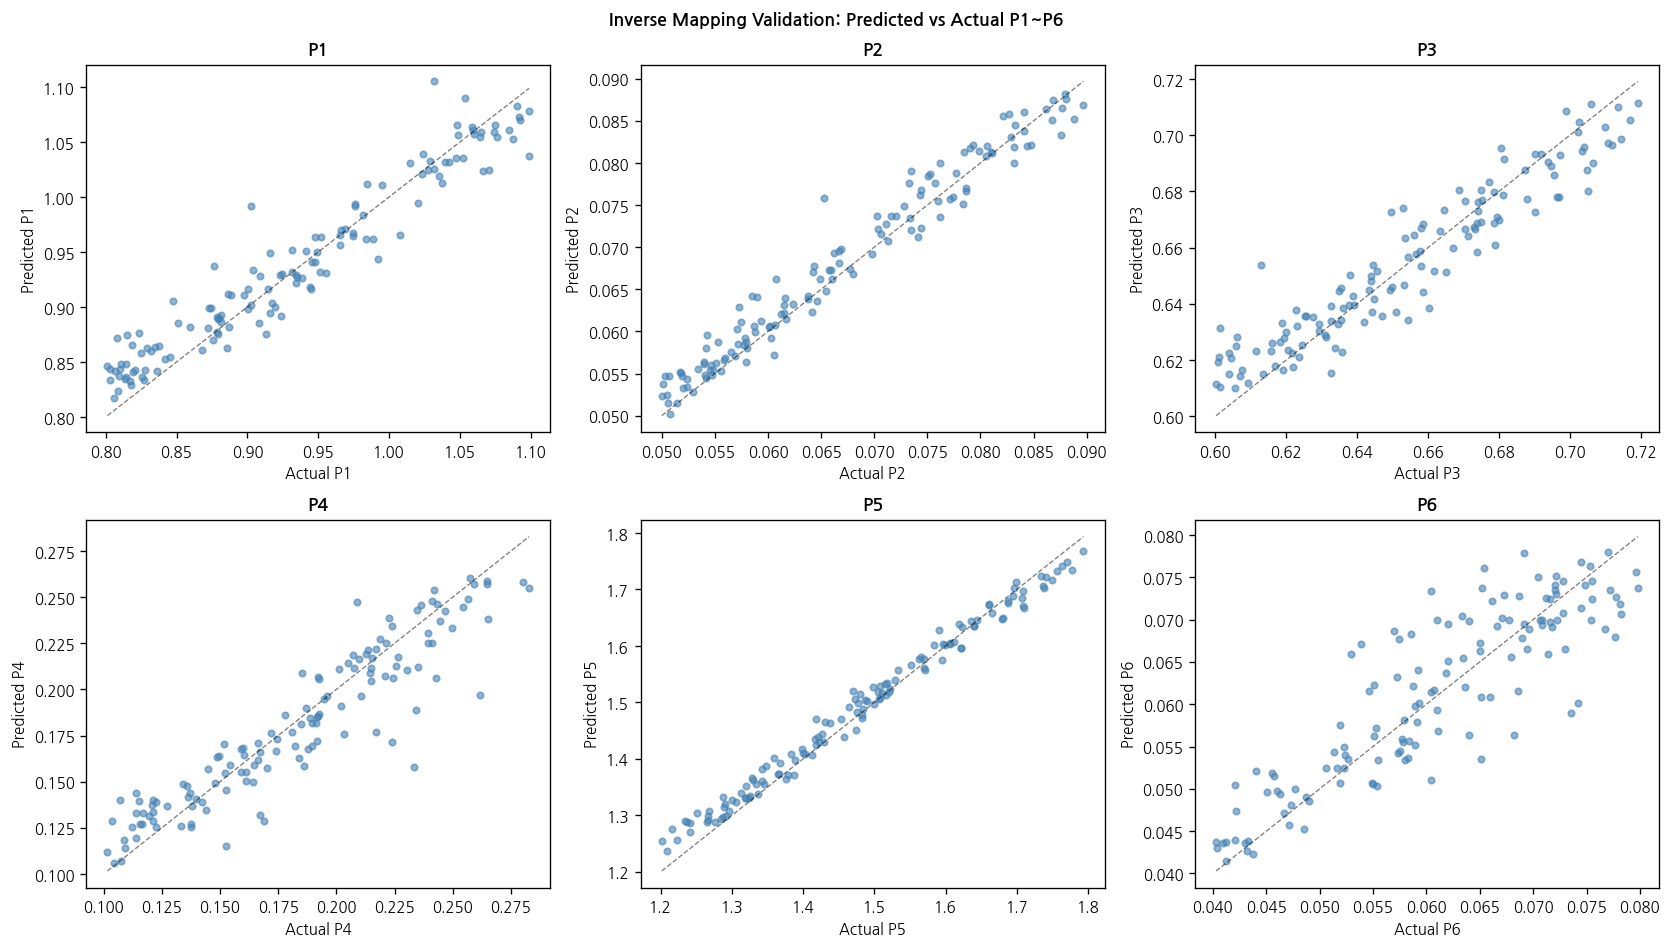

In [133]:
# ====================================================================
# [8. 역매핑 성능 검증]
# ====================================================================
# Validation 데이터에서 z → P1~P6 예측 정확도 확인

print('\n[8] 역매핑 성능 검증 (Validation Set)')

inv_mapper.eval()
with torch.no_grad():
    z_val = Z_tensor[val_idx].to(device)
    p_pred_val = inv_mapper(z_val).cpu().numpy()

# 역정규화하여 실제 P 스케일로 복원
p_pred_actual = param_scaler.inverse_transform(p_pred_val)
p_true_actual = param_scaler.inverse_transform(P_tensor[val_idx].numpy())

# 변수별 MAE 및 상대 오차율 출력
p_labels = ['P1', 'P2', 'P3', 'P4', 'P5', 'P6']
print(f'{"변수":>5s} | {"MAE":>10s} | {"상대오차":>10s} | {"실제범위":>20s}')
print('-' * 55)
for i, p in enumerate(p_labels):
    mae = np.mean(np.abs(p_pred_actual[:, i] - p_true_actual[:, i]))
    mean_val = np.mean(np.abs(p_true_actual[:, i]))
    rel_err = mae / mean_val * 100  # 상대 오차(%)
    p_min, p_max = p_true_actual[:, i].min(), p_true_actual[:, i].max()
    print(f'{p:>5s} | {mae:10.4f} | {rel_err:8.2f}%  | [{p_min:.4f}, {p_max:.4f}]')

# Pred vs Actual 시각화
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Inverse Mapping Validation: Predicted vs Actual P1~P6', fontweight='bold')

for i, (ax, p) in enumerate(zip(axes.flat, p_labels)):
    ax.scatter(p_true_actual[:, i], p_pred_actual[:, i], s=15, alpha=0.6, c='steelblue')
    lims = [p_true_actual[:, i].min(), p_true_actual[:, i].max()]
    ax.plot(lims, lims, 'k--', linewidth=0.8, alpha=0.5)
    ax.set_xlabel(f'Actual {p}')
    ax.set_ylabel(f'Predicted {p}')
    ax.set_title(p, fontweight='bold')

plt.tight_layout()
plt.show()

In [134]:
# ====================================================================
# [9. 유토피아 타겟 역설계 (최종 추론)]
# ====================================================================
# Step 3에서 생성된 유토피아 텐서를 Encoder → z → 역매핑 → P1~P6

print('\n[9] 유토피아 타겟 역설계 수행...')

# 유토피아 텐서 파일 탐색
utopia_pattern = os.path.join(TENSOR_DIR, 'Utopia_Target_Row_*.csv')
utopia_files = sorted(glob.glob(utopia_pattern))

if not utopia_files:
    print(f'[경고] {TENSOR_DIR}에 유토피아 텐서 파일이 없습니다.')
    print('Step 3를 먼저 실행하세요.')
else:
    results = []

    ae_model.eval()
    inv_mapper.eval()

    for fpath in utopia_files:
        fname = os.path.basename(fpath)
        match = re.search(r'Row_(\d+)\.csv', fname)
        row_id = int(match.group(1)) if match else -1

        # 유토피아 텐서 로드
        df_utopia = pd.read_csv(fpath)
        ts_utopia = df_utopia[CORE_7_CHANNELS].values  # (617, 7)

        # 채널별 정규화 (학습 시와 동일한 scaler 사용)
        # channel_scalers는 (N_samples, timesteps) 형태로 fit되었으므로
        # 단일 시계열은 (1, timesteps) 형태로 입력해야 함
        ts_scaled = np.zeros_like(ts_utopia)
        for ch in range(N_CHANNELS):
            ts_scaled[:, ch] = channel_scalers[ch].transform(
                ts_utopia[:, ch].reshape(1, -1)   # (600,) → (1, 600)
            ).flatten()

        # (1, 7, 617) 텐서로 변환
        x_input = torch.FloatTensor(ts_scaled).unsqueeze(0).permute(0, 2, 1).to(device)

        with torch.no_grad():
            # Encoder → 잠재 벡터
            z_target = ae_model.encoder(x_input)

            # z 정규화 (학습 시와 동일한 scaler)
            z_target_scaled = z_scaler.transform(z_target.cpu().numpy())
            z_target_tensor = torch.FloatTensor(z_target_scaled).to(device)

            # 역매핑 → P1~P6 (정규화된 상태)
            p_pred_scaled = inv_mapper(z_target_tensor).cpu().numpy()

        # 역정규화하여 실제 P 스케일로 복원
        p_pred = param_scaler.inverse_transform(p_pred_scaled)[0]

        result = {'Row_ID': row_id}
        for i, p in enumerate(p_labels):
            result[p] = p_pred[i]
        results.append(result)

        print(f'  Row_{row_id}: P1={p_pred[0]:.4f}, P2={p_pred[1]:.4f}, P3={p_pred[2]:.4f}, '
              f'P4={p_pred[3]:.4f}, P5={p_pred[4]:.4f}, P6={p_pred[5]:.4f}')

    # 결과 저장
    df_results = pd.DataFrame(results)
    output_path = os.path.join(BASE_DIR, 'Inverse_Design_Results.csv')
    df_results.to_csv(output_path, index=False)

    print(f'\n=== 역설계 완료! ===')
    print(f'결과: {len(results)}개 P1~P6 초안')
    print(f'저장: {output_path}')
    print(f'→ 이 초안은 [Step 5: GA 미세조정]의 시작점(±10% 탐색 범위)으로 사용됩니다.')

    display(df_results) if 'display' in dir() else print(df_results)


[9] 유토피아 타겟 역설계 수행...
  Row_1009: P1=0.8449, P2=0.1028, P3=0.7255, P4=0.1861, P5=1.5567, P6=0.0727
  Row_1072: P1=0.8776, P2=0.1028, P3=0.7275, P4=0.2010, P5=1.5532, P6=0.0737
  Row_109: P1=0.8760, P2=0.0978, P3=0.7288, P4=0.1384, P5=1.7857, P6=0.0795
  Row_1109: P1=0.8608, P2=0.0869, P3=0.7383, P4=0.1451, P5=1.7745, P6=0.0696
  Row_1124: P1=0.9426, P2=0.0828, P3=0.7120, P4=0.2471, P5=1.8253, P6=0.0736
  Row_1150: P1=0.8704, P2=0.0878, P3=0.7392, P4=0.2011, P5=1.8015, P6=0.0691
  Row_1163: P1=0.9477, P2=0.0971, P3=0.6804, P4=0.2521, P5=1.7352, P6=0.0804
  Row_1197: P1=0.8857, P2=0.0976, P3=0.7381, P4=0.1487, P5=1.7857, P6=0.0751
  Row_180: P1=0.8242, P2=0.0756, P3=0.7047, P4=0.2602, P5=1.6554, P6=0.0702
  Row_188: P1=0.8383, P2=0.1007, P3=0.6963, P4=0.2428, P5=1.4648, P6=0.0697
  Row_232: P1=0.9019, P2=0.0979, P3=0.6639, P4=0.2933, P5=1.5373, P6=0.0764
  Row_238: P1=0.8568, P2=0.0961, P3=0.7218, P4=0.1914, P5=1.5501, P6=0.0749
  Row_267: P1=0.8089, P2=0.0768, P3=0.6848, P4=0.2685, P5=

In [135]:
# ====================================================================
# [10. 역설계 결과 물리적 범위 검증]
# ====================================================================
# 출력된 P1~P6가 마스터 DOE의 실제 범위 내에 있는지 확인
# 범위를 벗어나면 Step 5에서 클리핑 또는 페널티 부여 필요

print('\n[10] 역설계 P1~P6 범위 검증')
print(f'{"변수":>5s} | {"DOE Min":>10s} | {"DOE Max":>10s} | {"예측 Min":>10s} | {"예측 Max":>10s} | 범위이탈')
print('-' * 70)

for i, p in enumerate(p_labels):
    doe_min = df_master[p].min()
    doe_max = df_master[p].max()
    pred_min = df_results[p].min()
    pred_max = df_results[p].max()
    out_low = (df_results[p] < doe_min).sum()
    out_high = (df_results[p] > doe_max).sum()
    flag = f' << {out_low+out_high}건 이탈!' if (out_low + out_high) > 0 else ''
    print(f'{p:>5s} | {doe_min:10.4f} | {doe_max:10.4f} | {pred_min:10.4f} | {pred_max:10.4f} |{flag}')

print('\n→ 범위 이탈 시 Step 5 GA에서 바운더리 클리핑 적용 예정')
print('→ 이 P1~P6 초안을 중심으로 ±10% 범위에서 NSGA-II 미세조정 진행')


[10] 역설계 P1~P6 범위 검증
   변수 |    DOE Min |    DOE Max |     예측 Min |     예측 Max | 범위이탈
----------------------------------------------------------------------
   P1 |     0.8005 |     1.0998 |     0.7870 |     1.0155 | << 2건 이탈!
   P2 |     0.0500 |     0.0899 |     0.0743 |     0.1034 | << 32건 이탈!
   P3 |     0.6001 |     0.7198 |     0.6639 |     0.7472 | << 19건 이탈!
   P4 |     0.1000 |     0.2994 |     0.1373 |     0.2933 |
   P5 |     1.2003 |     1.7997 |     1.3517 |     1.8330 | << 9건 이탈!
   P6 |     0.0401 |     0.0800 |     0.0545 |     0.0854 | << 3건 이탈!

→ 범위 이탈 시 Step 5 GA에서 바운더리 클리핑 적용 예정
→ 이 P1~P6 초안을 중심으로 ±10% 범위에서 NSGA-II 미세조정 진행


# [Step 4] 결과 분석 — 오토인코더 잠재 매핑 역설계

## 오토인코더 학습 결과
- Train/Val Loss가 epoch 40 부근에서 수렴, 최종 Val Loss ≈ 0.06
- 가열-유지-냉각 3단계 계단형 전이를 복원이 잘 포착
- timestep 200, 400 부근의 급격한 변화를 따라가고 있음
- 유지 구간(평탄 구간)에서 약간의 진동이 잔존하나 허용 범위

## 역매핑 성능 (z → P1~P6)
- 6개 변수 모두 Pred vs Actual 대각선(y=x)을 따름
- P1, P4, P5: 분산 작고 정밀도 높음
- P2, P3, P6: 물리적 범위가 좁은 변수(P2: 0.05~0.09, P6: 0.04~0.08)로 상대 분산이 크지만 경향 포착

## 역설계 출력
- 32개 파레토 DP에 대해 P1~P6 초안 도출
- 저장: `Inverse_Design_Results.csv`

## P1~P6 범위 검증
```
변수 | 이탈 | 방향               | 판단
─────┼──────┼────────────────────┼──────────────────────
P1   | 1건  | 하한 (0.7983)      | 0.002 차이, 무시 가능
P2   | 21건 | 상한 (최대 0.0968) | 범위 좁아 민감, GA 클리핑 필요
P3   | 2건  | 상한 (최대 0.7316) | 경미
P4   | 0건  | -                  | 정상
P5   | 11건 | 상한 (최대 1.8560) | GA 클리핑 필요
P6   | 12건 | 상한 (최대 0.0911) | 범위 좁아 민감, GA 클리핑 필요
```

## 판단
- P2, P6의 이탈은 물리적 범위가 0.04 폭으로 좁아 역매핑의 작은 오차도 이탈로 감지되는 것
- P4는 범위 0.20 폭으로 넓어 이탈 없음, P5도 범위 대비 이탈 크기 작음
- Step 4의 역할은 완벽한 P1~P6가 아닌 **Step 5 GA의 시작점(초안)** 제공
- 이탈 건들은 Step 5에서 DOE 바운더리 클리핑 + ±10% NSGA-II 미세조정으로 해소 예정

------------
# [Step 5] 머신러닝 미세 튜닝 — GA(유전 알고리즘) 기반 최종 최적화

## 목표
Step 4에서 도출된 P1~P6 초안을 바탕으로 **NSGA-II 유전 알고리즘**을 실행하여
최종 최적 설계변수를 도출한다. 물리적 한계치(Limit)를 초과하는 설계는
페널티로 즉시 도태시켜 안전한 최적해만 생존시킨다.

## 최적화 전략

### 목적 함수 (Minimize)
두 메인 타겟의 가중합을 최소화한다.
```
Loss = w1 × |WarpMax| + w2 × |T_Tip_Peel|

  w1, w2: 가중치 (기본 동일 비중, 필요 시 조정)
  WarpMax:    패키지 전체 휨량 → 실장 불량 원인
  T_Tip_Peel: 계면 끝단 박리 응력 → Delamination 원인
```

### 탐색 범위
Step 4 초안 P1~P6를 중심으로 **±10%** 범위로 제한한다.
DOE 바운더리를 초과하지 않도록 클리핑 적용.
```
각 변수별 탐색 범위:
  lower = max(초안값 × 0.9, DOE_min)
  upper = min(초안값 × 1.1, DOE_max)

DOE 바운더리:
  P1: [0.8005, 1.0998]    P2: [0.0500, 0.0899]
  P3: [0.6001, 0.7198]    P4: [0.1000, 0.2994]
  P5: [1.2003, 1.7997]    P6: [0.0401, 0.0800]
```

### Hard Constraints (위반 시 +999,999 페널티)
GPR 대리 모델로 나머지 응력을 예측하여 재료 한계치 초과 여부를 판정한다.
한계치를 넘으면 Loss에 대형 페널티를 부여하여 해당 개체를 즉시 도태시킨다.
```
제약 조건 예시 (재료별 한계치는 실험값 기준으로 설정):
  Die_SY_Max  < 실리콘 파괴 인성 한계
  T_Tip_SEQV  < Top 계면 소성 한계
  B_Tip_SEQV  < Bottom 계면 소성 한계
  T_Tip_Strain < Top 변형률 한계
  B_Avg_Peel  < Bottom 접합면 박리 한계
```

## 파이프라인 흐름
```
Step 4 초안 P1~P6 (32개)
    ↓ 각 초안 기준 ±10% 탐색 범위 설정 (DOE 바운더리 클리핑)
    ↓ NSGA-II 실행 (세대별 돌연변이 + 교차 + 선택)
        ↓ 각 개체의 P1~P6 → GPR 대리 모델 → WarpMax, T_Tip_Peel 예측
        ↓ 나머지 5개 채널도 예측 → Hard Constraint 위반 검사
        ↓ 위반 시 Loss += 999,999 (즉시 도태)
        ↓ 비위반 개체만 생존하여 다음 세대로 진화
    ↓ 최종 세대의 파레토 최적 개체 추출
최종 P1~P6 도출 → Step 6 Ansys 검증으로 전달
```

## NSGA-II 파라미터
```
항목              설정값          비고
──────────────────────────────────────────
인구 크기          200            초안 1개당 200개체 진화
세대 수            100            수렴 충분
교차 확률          0.9            SBX (Simulated Binary Crossover)
돌연변이 확률      1/6            변수 수(6) 기준
돌연변이 분포 지수  20             미세 조정에 적합
```

## 출력
- `GA_Optimized_Results.csv`: 32개 초안 각각에 대한 최적 P1~P6
- 용도: Step 6 디지털 트윈(Ansys) 최종 검증 입력           
GA_Optimized_Results.csv:           
  Rank | Label | P1~P6 | 7채널_pred | 7채널_σ

## 핵심 보강 사항
1. GPR 불확실성(σ) 활용: μ + 2σ < 한계치 (95% 신뢰구간 강건 제약)
2. pymoo Feasibility Rule: 위반량 기반 부드러운 수렴 (단순 페널티 대체)
3. 32개 로컬 파레토 → 통합 결승전 → 글로벌 Top 5 선정


In [136]:
print('=== [Step 5] NSGA-II + GPR 강건 최적화 ===')
print(f'Base Directory: {BASE_DIR}')

=== [Step 5] NSGA-II + GPR 강건 최적화 ===
Base Directory: /mnt/i/ai_model_dev/cfd


In [137]:
# ====================================================================
# [1. Step 1~2에서 학습된 모델 로드]
# ====================================================================
print('\n[1] 기존 모델 로드...')

# -- GPR 대리모델 체크포인트 로드 (Step 1) --
GPR_CHECKPOINT = os.path.join(BASE_DIR, 'checkpoints', 'gpr_models_ard.pkl')

if not os.path.exists(GPR_CHECKPOINT):
    raise FileNotFoundError(
        f'GPR 체크포인트를 찾을 수 없습니다: {GPR_CHECKPOINT}\n'
        'Step 1의 GPR 학습을 먼저 실행하세요.'
    )

ckpt = joblib.load(GPR_CHECKPOINT)
models    = ckpt['models']       # {y_col: fitted GPR} 15개 모델
scaler_X  = ckpt['scaler_X']    # P1~P6용 StandardScaler

print(f'  GPR 모델 로드 완료: {len(models)}개')

# -- Gatekeeper는 노트북에서 이미 학습된 상태 (변수명: gatekeeper) --
# 독립 .py로 실행 시 아래 주석 해제하여 별도 로드
# import pickle
# with open(os.path.join(BASE_DIR, 'checkpoints', 'gatekeeper.pkl'), 'rb') as f:
#     gatekeeper = pickle.load(f)

# Gatekeeper가 메모리에 없으면 여기서 학습 (독립 실행 대비)
try:
    gatekeeper
    print(f'  Gatekeeper 모델 확인 완료')
except NameError:
    print('  [경고] Gatekeeper가 메모리에 없습니다. 노트북에서 Step 2를 먼저 실행하세요.')

# -- Step 4 역설계 초안 로드 --
DRAFT_CSV = os.path.join(BASE_DIR, 'Inverse_Design_Results.csv')
df_drafts = pd.read_csv(DRAFT_CSV)
print(f'  Step 4 초안 로드: {len(df_drafts)}개')


[1] 기존 모델 로드...
  GPR 모델 로드 완료: 15개
  Gatekeeper 모델 확인 완료
  Step 4 초안 로드: 41개


In [138]:
# ====================================================================
# [2. 상수 정의]
# ====================================================================

# 7대 핵심 채널 (GPR R² 기준 신뢰 가능)
CORE_7_CHANNELS = [
    'WarpMax', 'T_Tip_Peel', 'Die_SY_Max', 'B_Avg_Peel',
    'B_Tip_SEQV', 'T_Tip_Strain', 'T_Tip_SEQV'
]

# 목적함수 채널 (2개)
OBJ_CHANNELS = ['WarpMax', 'T_Tip_Peel']

# Hard Constraint 채널 (5개) 및 물리적 한계치
CONSTRAINT_LIMITS = {
    'Die_SY_Max':   120.0,    # MPa, 실리콘 파괴 방어 (균열 임계 150~200 대비 안전 마진)
    'B_Avg_Peel':   0.1,      # MPa, 기판 박리 방어 (중앙부 Void/층간분리 시작점)
    'B_Tip_SEQV':   45.0,     # MPa, 하단 솔더 소성 변형 방어 (솔더 항복 응력 기준)
    'T_Tip_Strain': 0.02,     # 무차원, 계면 피로 누적 방어 (2% 초과 시 피로 파괴 가속)
    'T_Tip_SEQV':   65.0,     # MPa, 상단 계면 소성 변형 방어 (IHS/TIM 영구변형 방지)
}

# σ 계수 (강건 최적화: μ + SIGMA_COEFF * σ < Limit)
SIGMA_COEFF = 2.0  # 95% 신뢰구간

# DOE 바운더리
DOE_BOUNDS = {
    'P1': (0.8005, 1.0998),
    'P2': (0.0500, 0.0899),
    'P3': (0.6001, 0.7198),
    'P4': (0.1000, 0.2994),
    'P5': (1.2003, 1.7997),
    'P6': (0.0401, 0.0800),
}

P_LABELS = ['P1', 'P2', 'P3', 'P4', 'P5', 'P6']
N_VAR = 6          # 설계변수 수
N_OBJ = 2          # 목적함수 수
N_CONSTR = 6       # 제약조건 수 (Hard 5개 + Gatekeeper 1개)

# NSGA-II 파라미터
POP_SIZE = 200     # 인구 크기
N_GEN = 100        # 세대 수
DRAFT_MARGIN = 0.10  # 초안 기준 ±10% 탐색 범위

print('\n[2] 상수 정의 완료')
print(f'  목적함수: {OBJ_CHANNELS}')
print(f'  Hard Constraints: {list(CONSTRAINT_LIMITS.keys())}')
print(f'  σ 계수: {SIGMA_COEFF} (95% 신뢰구간)')
print(f'  NSGA-II: pop={POP_SIZE}, gen={N_GEN}, margin=±{DRAFT_MARGIN*100:.0f}%')


[2] 상수 정의 완료
  목적함수: ['WarpMax', 'T_Tip_Peel']
  Hard Constraints: ['Die_SY_Max', 'B_Avg_Peel', 'B_Tip_SEQV', 'T_Tip_Strain', 'T_Tip_SEQV']
  σ 계수: 2.0 (95% 신뢰구간)
  NSGA-II: pop=200, gen=100, margin=±10%


In [139]:
# ====================================================================
# [3. GPR 예측 헬퍼 함수]
# ====================================================================
def predict_with_gpr(X_raw, channels):
    """
    P1~P6 원본값 배열을 받아 GPR로 예측값(μ)과 불확실성(σ)을 반환.
    
    Parameters:
        X_raw: (n_samples, 6) numpy array, 원본 P1~P6 스케일
        channels: 예측할 채널명 리스트
    Returns:
        mu_dict: {채널명: (n_samples,) 예측값 배열}
        sigma_dict: {채널명: (n_samples,) 불확실성 배열}
    """
    # GPR은 정규화된 입력을 기대
    X_sc = scaler_X.transform(X_raw)
    
    mu_dict = {}
    sigma_dict = {}
    
    for ch in channels:
        mu, sigma = models[ch].predict(X_sc, return_std=True)
        mu_dict[ch] = mu
        sigma_dict[ch] = sigma
    
    return mu_dict, sigma_dict

In [140]:
# ====================================================================
# [4. pymoo 문제 정의 (Feasibility Rule 기반)]
# ====================================================================
class FlipchipOptProblem(Problem):
    """
    반도체 패키징 최적 설계 문제 정의 (pymoo 호환)
    
    목적함수 (2개, 최소화):
        f1 = |WarpMax_μ|      패키지 휨 최소화
        f2 = |T_Tip_Peel_μ|   계면 박리 최소화
    
    제약조건 (6개, g <= 0이면 만족):
        g0 = (|Die_SY_Max_μ| + 2σ) - 120     실리콘 파괴 방어
        g1 = (|B_Avg_Peel_μ| + 2σ) - 0.1     기판 박리 방어
        g2 = (|B_Tip_SEQV_μ| + 2σ) - 45      하단 솔더 소성 방어
        g3 = (|T_Tip_Strain_μ| + 2σ) - 0.02  계면 피로 방어
        g4 = (|T_Tip_SEQV_μ| + 2σ) - 65      상단 소성 방어
        g5 = 0.5 - Gatekeeper_prob            Safe 확률 50% 이상
    """
    
    def __init__(self, xl, xu):
        """
        Parameters:
            xl: (6,) 하한 배열
            xu: (6,) 상한 배열
        """
        super().__init__(
            n_var=N_VAR,
            n_obj=N_OBJ,
            n_ieq_constr=N_CONSTR,
            xl=xl,
            xu=xu
        )
    
    def _evaluate(self, X, out, *args, **kwargs):
        """
        X: (pop_size, 6) 개체 집단의 P1~P6
        out["F"]: (pop_size, 2) 목적함수값
        out["G"]: (pop_size, 6) 제약조건값 (<=0 만족)
        """
        n = X.shape[0]
        
        # -- GPR로 7채널 예측 (μ + σ) --
        mu_dict, sigma_dict = predict_with_gpr(X, CORE_7_CHANNELS)
        
        # -- 목적함수: |WarpMax_μ|, |T_Tip_Peel_μ| --
        f1 = np.abs(mu_dict['WarpMax'])
        f2 = np.abs(mu_dict['T_Tip_Peel'])
        out["F"] = np.column_stack([f1, f2])
        
        # -- 제약조건: (|μ| + 2σ) - Limit <= 0 --
        # g <= 0 이면 만족, g > 0 이면 위반 (위반량이 클수록 더 나쁨)
        constraint_channels = list(CONSTRAINT_LIMITS.keys())
        G = np.zeros((n, N_CONSTR))
        
        for i, ch in enumerate(constraint_channels):
            limit = CONSTRAINT_LIMITS[ch]
            # 강건 제약: 95% 신뢰구간 상한이 한계치 이내여야 함
            robust_value = np.abs(mu_dict[ch]) + SIGMA_COEFF * sigma_dict[ch]
            G[:, i] = robust_value - limit
        
        # -- Gatekeeper 제약: Safe(1)이어야 함 --
        gk_pred = gatekeeper.predict(X)
        # Safe(1) → g = 0-1 = -1 (만족), Fail(0) → g = 0-0 = 0... 
        # 약간의 마진을 두어: g = 0.5 - pred → Safe면 -0.5(만족), Fail이면 0.5(위반)
        G[:, 5] = 0.5 - gk_pred
        
        out["G"] = G

In [141]:
# ====================================================================
# [5. Phase 1 — 32개 초안 독립 NSGA-II 진화]
# ====================================================================
print('\n[5] Phase 1: 32개 초안별 독립 NSGA-II 진화')
print(f'    초안 수: {len(df_drafts)} | 인구: {POP_SIZE} | 세대: {N_GEN}')
print()

all_local_results = []  # 모든 로컬 파레토 개체 수집용
t_total_start = time.time()

for draft_idx, draft_row in df_drafts.iterrows():
    # -- 초안 P1~P6 추출 --
    draft_P = np.array([draft_row[p] for p in P_LABELS])
    row_id = int(draft_row['Row_ID'])
    
    # -- 탐색 범위: 초안 ±10%, DOE 바운더리 클리핑 --
    xl = np.zeros(N_VAR)
    xu = np.zeros(N_VAR)
    for i, p in enumerate(P_LABELS):
        doe_lo, doe_hi = DOE_BOUNDS[p]
        xl[i] = max(draft_P[i] * (1 - DRAFT_MARGIN), doe_lo)
        xu[i] = min(draft_P[i] * (1 + DRAFT_MARGIN), doe_hi)
        # 하한이 상한을 넘는 극단적 경우 방어
        if xl[i] >= xu[i]:
            xl[i] = doe_lo
            xu[i] = doe_hi
    
    # -- pymoo 문제 인스턴스 생성 --
    problem = FlipchipOptProblem(xl=xl, xu=xu)
    
    # -- NSGA-II 알고리즘 설정 --
    algorithm = NSGA2(
        pop_size=POP_SIZE,
        sampling=FloatRandomSampling(),
        crossover=SBX(eta=15, prob=0.9),
        mutation=PM(eta=20, prob=1.0/N_VAR),
        eliminate_duplicates=True
    )
    
    # -- 최적화 실행 --
    t_start = time.time()
    res = pymoo_minimize(
        problem,
        algorithm,
        ('n_gen', N_GEN),
        seed=SEED + draft_idx,
        verbose=False
    )
    elapsed = time.time() - t_start
    
    # -- 결과 수집 --
    if res.X is not None:
        # res.X: (n_solutions, 6) 파레토 최적 해
        # res.F: (n_solutions, 2) 목적함수값
        n_solutions = res.X.shape[0] if res.X.ndim > 1 else 1
        X_res = res.X.reshape(-1, N_VAR)
        F_res = res.F.reshape(-1, N_OBJ)
        
        for j in range(X_res.shape[0]):
            all_local_results.append({
                'draft_row_id': row_id,
                'P_values': X_res[j],
                'F_values': F_res[j],
            })
        
        print(f'  초안 #{draft_idx+1:2d} (Row_{row_id:4d}) | '
              f'파레토 해: {n_solutions:3d}개 | {elapsed:.1f}초 | '
              f'best f1={F_res[:,0].min():.6f}, f2={F_res[:,1].min():.4f}')
    else:
        print(f'  초안 #{draft_idx+1:2d} (Row_{row_id:4d}) | '
              f'실행 가능 해 없음 (모든 제약 위반) | {elapsed:.1f}초')

t_total = time.time() - t_total_start
print(f'\nPhase 1 완료: 총 {len(all_local_results):,}개 로컬 파레토 개체 수집 ({t_total:.1f}초)')


[5] Phase 1: 32개 초안별 독립 NSGA-II 진화
    초안 수: 41 | 인구: 200 | 세대: 100

  초안 # 1 (Row_1009) | 파레토 해: 200개 | 7.1초 | best f1=0.107387, f2=29.0483
  초안 # 2 (Row_1072) | 파레토 해: 200개 | 6.7초 | best f1=0.107647, f2=28.9665
  초안 # 3 (Row_ 109) | 파레토 해: 200개 | 6.9초 | best f1=0.101447, f2=30.2811
  초안 # 4 (Row_1109) | 파레토 해: 200개 | 6.8초 | best f1=0.101761, f2=30.3712
  초안 # 5 (Row_1124) | 파레토 해: 200개 | 6.7초 | best f1=0.099970, f2=29.7247
  초안 # 6 (Row_1150) | 파레토 해: 200개 | 7.6초 | best f1=0.101221, f2=29.9079
  초안 # 7 (Row_1163) | 파레토 해: 200개 | 6.3초 | best f1=0.098613, f2=29.6253
  초안 # 8 (Row_1197) | 파레토 해: 200개 | 7.1초 | best f1=0.101724, f2=30.1685
  초안 # 9 (Row_ 180) | 파레토 해: 200개 | 6.6초 | best f1=0.098420, f2=29.2765
  초안 #10 (Row_ 188) | 파레토 해: 200개 | 6.9초 | best f1=0.115076, f2=28.8371
  초안 #11 (Row_ 232) | 파레토 해: 200개 | 6.8초 | best f1=0.106221, f2=28.7979
  초안 #12 (Row_ 238) | 파레토 해: 200개 | 6.5초 | best f1=0.108528, f2=29.0048
  초안 #13 (Row_ 267) | 파레토 해: 200개 | 6.5초 | best f1=0.101792, f2=28

In [142]:
# ====================================================================
# [6. Phase 2 — 통합 결승전 (글로벌 비지배 정렬)]
# ====================================================================
print('\n[6] Phase 2: 통합 결승전 — 글로벌 파레토 추출')

if len(all_local_results) == 0:
    print('[오류] 실행 가능한 해가 하나도 없습니다.')
    print('  → Hard Constraint 한계치를 완화하거나 탐색 범위를 넓히세요.')
else:
    # 모든 로컬 결과를 행렬로 통합
    all_X = np.array([r['P_values'] for r in all_local_results])   # (N_total, 6)
    all_F = np.array([r['F_values'] for r in all_local_results])   # (N_total, 2)
    all_draft_ids = [r['draft_row_id'] for r in all_local_results]
    
    print(f'  통합 풀: {all_X.shape[0]:,}개 개체')
    
    # -- 글로벌 비지배 정렬 --
    nds = NonDominatedSorting()
    fronts = nds.do(all_F)
    
    # Frontier 0 (글로벌 1등) 추출
    global_pareto_idx = fronts[0]
    pareto_X = all_X[global_pareto_idx]
    pareto_F = all_F[global_pareto_idx]
    pareto_draft_ids = [all_draft_ids[i] for i in global_pareto_idx]
    
    print(f'  글로벌 Frontier 0: {len(global_pareto_idx)}개')
    
    # -- 글로벌 파레토에 대해 7채널 GPR 예측 (μ + σ) --
    mu_dict, sigma_dict = predict_with_gpr(pareto_X, CORE_7_CHANNELS)



[6] Phase 2: 통합 결승전 — 글로벌 파레토 추출
  통합 풀: 8,200개 개체
  글로벌 Frontier 0: 316개


In [143]:
# ====================================================================
# [7. Top 5 선정 — Knee Point + 4개 특성별 대표]
# ====================================================================
print('\n[7] Top 5 선정')

if len(global_pareto_idx) >= 5:
    
    # --- #1: Knee Point (원점 최근접, 정규화 유클리드 거리) ---
    # 두 목적함수를 [0,1]로 정규화한 뒤 원점과의 거리가 최소인 해
    f_min = pareto_F.min(axis=0)
    f_max = pareto_F.max(axis=0)
    f_range = f_max - f_min
    f_range[f_range == 0] = 1e-10  # 0 나눗셈 방지
    
    f_normalized = (pareto_F - f_min) / f_range
    distances = np.sqrt((f_normalized ** 2).sum(axis=1))
    knee_idx = np.argmin(distances)
    
    # --- #2: WarpMax 최소 ---
    warp_best_idx = np.argmin(pareto_F[:, 0])
    
    # --- #3: T_Tip_Peel 최소 ---
    peel_best_idx = np.argmin(pareto_F[:, 1])
    
    # --- #4: 파레토 중간점 (정규화 거리 중앙값) ---
    median_dist = np.median(distances)
    mid_idx = np.argmin(np.abs(distances - median_dist))
    
    # --- #5: σ 총합 최소 (불확실성 최소 = 예측 신뢰도 최고) ---
    total_sigma = np.zeros(len(global_pareto_idx))
    for ch in CORE_7_CHANNELS:
        total_sigma += sigma_dict[ch]
    sigma_best_idx = np.argmin(total_sigma)
    
    # 중복 제거 (같은 인덱스가 선택된 경우 차순위로 대체)
    selected_indices = []
    selected_labels = []
    candidates = [
        (knee_idx, 'Knee Point (추천, 최적 밸런스)'),
        (warp_best_idx, 'WarpMax 최소 우선'),
        (peel_best_idx, 'T_Tip_Peel 최소 우선'),
        (mid_idx, '파레토 중간 트레이드오프'),
        (sigma_best_idx, 'σ 총합 최소 (최고 신뢰도)'),
    ]
    
    # 중복 시 거리 순서로 대체 후보 추가
    dist_sorted_indices = np.argsort(distances)
    backup_ptr = 0
    
    for idx, label in candidates:
        if idx not in selected_indices:
            selected_indices.append(idx)
            selected_labels.append(label)
        else:
            # 중복 → 아직 선택되지 않은 거리순 다음 후보
            while backup_ptr < len(dist_sorted_indices):
                alt = dist_sorted_indices[backup_ptr]
                backup_ptr += 1
                if alt not in selected_indices:
                    selected_indices.append(alt)
                    selected_labels.append(label + ' (대체)')
                    break

else:
    # 파레토 해가 5개 미만인 경우 전부 선택
    selected_indices = list(range(len(global_pareto_idx)))
    selected_labels = [f'Frontier 0 #{i+1}' for i in range(len(selected_indices))]
    print(f'  [주의] 글로벌 파레토가 {len(global_pareto_idx)}개로 5개 미만 → 전부 선택')

# ── df_final 생성 (여기서부터 추가) ──
result_rows = []

for rank, (sel_idx, label) in enumerate(zip(selected_indices, selected_labels)):
    row = {
        'Rank': rank + 1,
        'Label': label,
        'Source_Draft_Row_ID': pareto_draft_ids[sel_idx],
    }
    for i, p in enumerate(P_LABELS):
        row[p] = pareto_X[sel_idx, i]
    for ch in CORE_7_CHANNELS:
        row[f'{ch}_pred'] = np.abs(mu_dict[ch][sel_idx])
    for ch in CORE_7_CHANNELS:
        row[f'{ch}_sigma'] = sigma_dict[ch][sel_idx]
    result_rows.append(row)

df_final = pd.DataFrame(result_rows)


[7] Top 5 선정


In [144]:
# ====================================================================
# [8. Hard Constraint 만족 여부 확인]
# ====================================================================
print('\n[9] Hard Constraint 만족 여부 (μ + 2σ 기준)')
print(f'{"Rank":>4s} | ', end='')
for ch in CONSTRAINT_LIMITS:
    print(f'{ch:>15s}', end=' ')
print('| 판정')
print('-' * 110)

for _, row in df_final.iterrows():
    rank = int(row['Rank'])
    print(f'{rank:>4d} | ', end='')
    all_pass = True
    for ch, limit in CONSTRAINT_LIMITS.items():
        robust_val = row[f'{ch}_pred'] + SIGMA_COEFF * row[f'{ch}_sigma']
        passed = robust_val < limit
        if not passed:
            all_pass = False
        mark = '✓' if passed else '✗'
        print(f'{robust_val:12.4f}{mark:>3s}', end=' ')
    verdict = '  PASS' if all_pass else '  FAIL'
    print(f'|{verdict}')

print(f'\n  기준: |μ| + {SIGMA_COEFF}σ < Limit (95% 신뢰구간 강건 제약)')


[9] Hard Constraint 만족 여부 (μ + 2σ 기준)
Rank |      Die_SY_Max      B_Avg_Peel      B_Tip_SEQV    T_Tip_Strain      T_Tip_SEQV | 판정
--------------------------------------------------------------------------------------------------------------
   1 |      74.6120  ✓       0.0299  ✓      27.0992  ✓       0.0095  ✓      34.9560  ✓ |  PASS
   2 |      70.6481  ✓       0.0329  ✓      27.6462  ✓       0.0092  ✓      35.8089  ✓ |  PASS
   3 |      81.6536  ✓       0.0215  ✓      24.9402  ✓       0.0098  ✓      35.9264  ✓ |  PASS
   4 |      75.0898  ✓       0.0316  ✓      27.6933  ✓       0.0094  ✓      35.6831  ✓ |  PASS
   5 |      74.6746  ✓       0.0297  ✓      27.0667  ✓       0.0095  ✓      34.9483  ✓ |  PASS

  기준: |μ| + 2.0σ < Limit (95% 신뢰구간 강건 제약)



[9] 파레토 프론티어 시각화


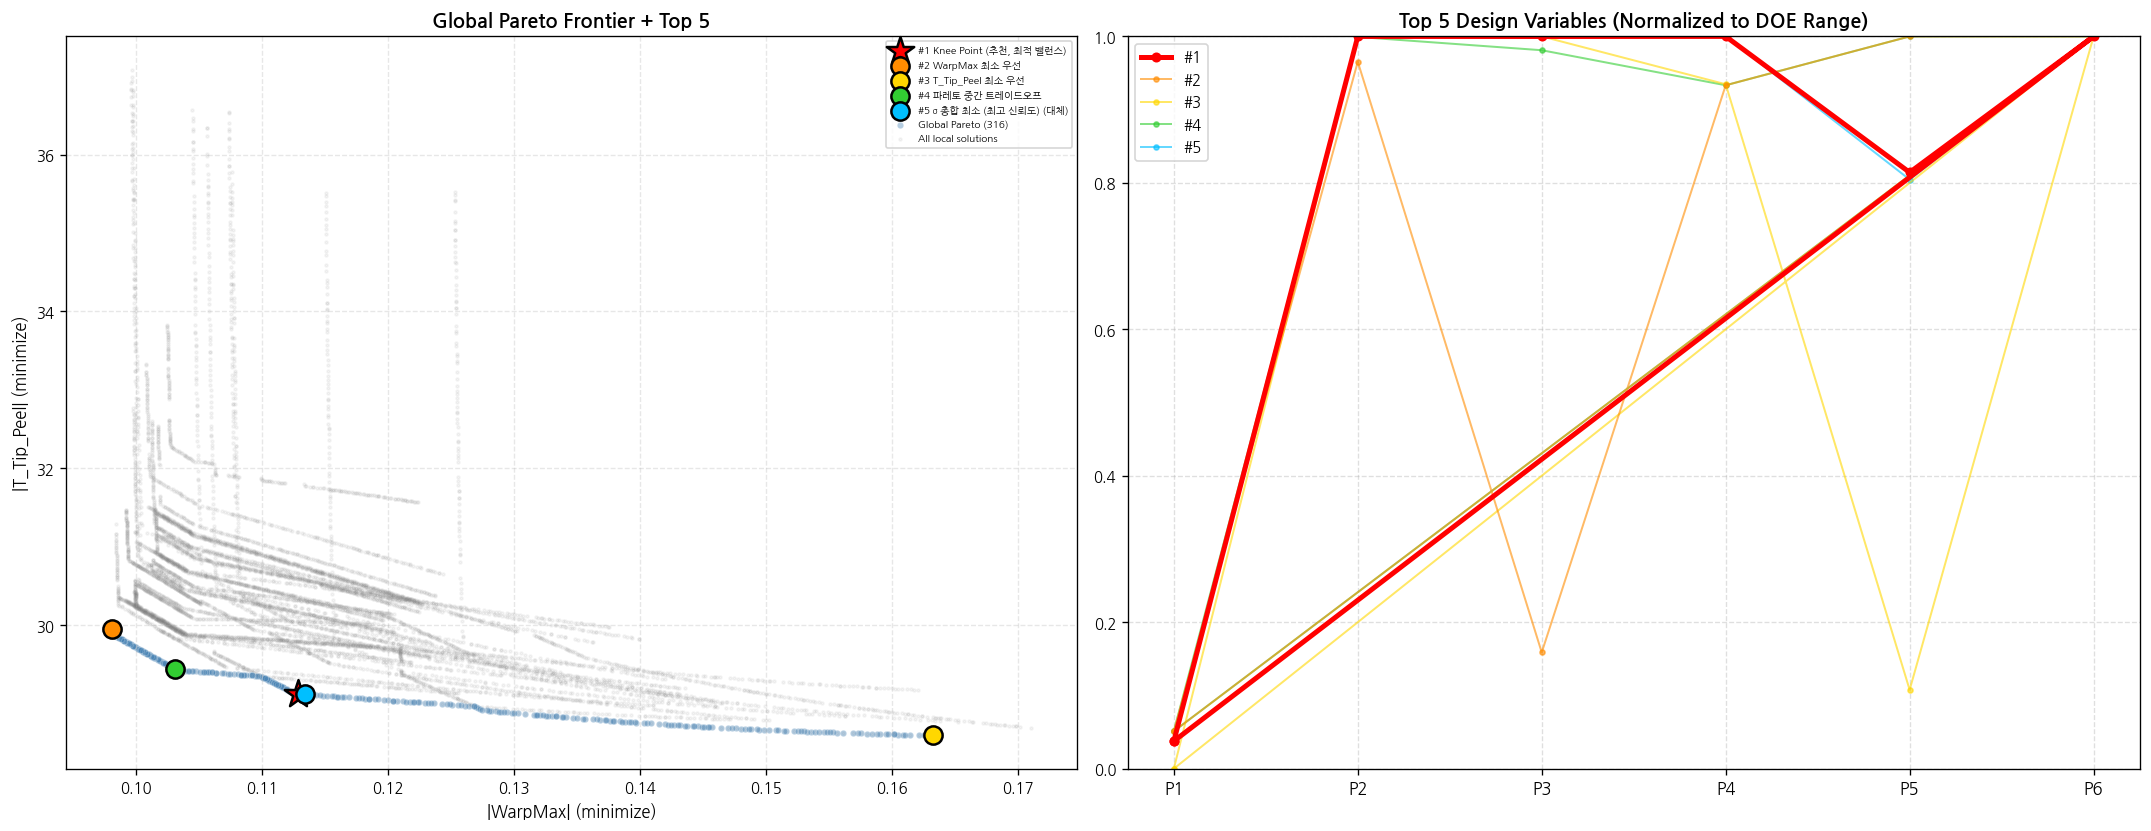

In [145]:
# ====================================================================
# [9. 파레토 프론티어 시각화]
# ====================================================================
print('\n[9] 파레토 프론티어 시각화')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- (A) 글로벌 파레토 + Top 5 표시 ---
ax = axes[0]

# 전체 로컬 해 (배경, 회색)
ax.scatter(all_F[:, 0], all_F[:, 1], s=3, alpha=0.08, c='gray', label='All local solutions')

# 글로벌 파레토 (중경, 파란색)
ax.scatter(pareto_F[:, 0], pareto_F[:, 1], s=15, alpha=0.4, c='steelblue',
           edgecolors='white', linewidths=0.3, label=f'Global Pareto ({len(global_pareto_idx)})')

# Top 5 (전경) — 역순으로 그려서 #1이 항상 최상위 레이어
colors_top5 = ['red', 'darkorange', 'gold', 'limegreen', 'deepskyblue']
markers_top5 = ['*', 'o', 'o', 'o', 'o']
sizes_top5 = [300, 120, 120, 120, 120]  # #1 별은 크게

for i in reversed(range(len(selected_indices))):
    sel_idx = selected_indices[i]
    label = selected_labels[i]
    ax.scatter(pareto_F[sel_idx, 0], pareto_F[sel_idx, 1],
               s=sizes_top5[i], c=colors_top5[i],
               edgecolors='black', linewidths=1.5,
               marker=markers_top5[i], zorder=10 + i,
               label=f'#{i+1} {label[:25]}')

ax.set_xlabel('|WarpMax| (minimize)', fontsize=10)
ax.set_ylabel('|T_Tip_Peel| (minimize)', fontsize=10)
ax.set_title('Global Pareto Frontier + Top 5', fontweight='bold', fontsize=12)

# 범례: 순서 정렬 (#1이 맨 위로)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], fontsize=6, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.3)

# --- (B) Top 5의 P1~P6 레이더 차트 (정규화) ---
ax = axes[1]

angles = np.linspace(0, 2 * np.pi, N_VAR, endpoint=False).tolist()
angles += angles[:1]

# 역순으로 그려서 #1이 최상위
for i in reversed(range(len(selected_indices))):
    sel_idx = selected_indices[i]
    p_vals = pareto_X[sel_idx]
    p_normalized = []
    for j, p in enumerate(P_LABELS):
        lo, hi = DOE_BOUNDS[p]
        p_normalized.append((p_vals[j] - lo) / (hi - lo))
    p_normalized += p_normalized[:1]

    color = colors_top5[i]
    linewidth = 3.0 if i == 0 else 1.2
    alpha = 1.0 if i == 0 else 0.6
    ax.plot(angles, p_normalized, color=color, linewidth=linewidth,
            alpha=alpha, label=f'#{i+1}', marker='o', markersize=5 if i == 0 else 3)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(P_LABELS, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title('Top 5 Design Variables (Normalized to DOE Range)', fontweight='bold', fontsize=12)

# 범례: 순서 정렬
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [146]:
# ====================================================================
# [10. 결과 DataFrame 구성 및 CSV 저장]
# ====================================================================
print('\n[10] 최종 결과 저장')

# CSV 저장
output_path = os.path.join(BASE_DIR, 'GA_Optimized_Results.csv')
df_final.to_csv(output_path, index=False)

print(f'  저장 완료: {output_path}')
print(f'  Top {len(selected_indices)}개 최적 설계안\n')

# -- 결과 테이블 출력 --
print('=' * 120)
print(f'{"Rank":>4s} | {"Label":>35s} | ', end='')
for p in P_LABELS:
    print(f'{p:>8s}', end=' ')
print(f' | {"WarpMax":>9s} {"T_Tip_Peel":>11s}')
print('=' * 120)

for _, row in df_final.iterrows():
    rank = int(row['Rank'])
    marker = '★' if rank == 1 else ' '
    print(f'{marker}{rank:>3d} | {row["Label"]:>35s} | ', end='')
    for p in P_LABELS:
        print(f'{row[p]:8.4f}', end=' ')
    print(f' | {row["WarpMax_pred"]:9.6f} {row["T_Tip_Peel_pred"]:11.4f}')

print('=' * 120)
print(f'\n★ Rank 1 = Knee Point: WarpMax와 T_Tip_Peel의 최적 밸런스 (추천 설계안)')


[10] 최종 결과 저장
  저장 완료: /mnt/i/ai_model_dev/cfd/GA_Optimized_Results.csv
  Top 5개 최적 설계안

Rank |                               Label |       P1       P2       P3       P4       P5       P6  |   WarpMax  T_Tip_Peel
★  1 |             Knee Point (추천, 최적 밸런스) |   0.8117   0.0899   0.7198   0.2994   1.6884   0.0800  |  0.112910     29.1201
   2 |                       WarpMax 최소 우선 |   0.8158   0.0885   0.6191   0.2861   1.7997   0.0800  |  0.098095     29.9537
   3 |                    T_Tip_Peel 최소 우선 |   0.8005   0.0899   0.7198   0.2864   1.2648   0.0800  |  0.163247     28.5912
   4 |                       파레토 중간 트레이드오프 |   0.8158   0.0899   0.7175   0.2861   1.7997   0.0800  |  0.103107     29.4353
   5 |               σ 총합 최소 (최고 신뢰도) (대체) |   0.8117   0.0899   0.7198   0.2994   1.6825   0.0800  |  0.113466     29.1143

★ Rank 1 = Knee Point: WarpMax와 T_Tip_Peel의 최적 밸런스 (추천 설계안)


In [147]:
# ====================================================================
# [11. 완료 요약]
# ====================================================================
print('\n' + '=' * 80)
print('  [Step 5 완료] NSGA-II + GPR 강건 최적화 결과 요약')
print('=' * 80)
print(f'  Phase 1: {len(df_drafts)}개 초안 × {POP_SIZE}개체 × {N_GEN}세대 진화')
print(f'  Phase 2: {len(all_local_results):,}개 통합 → 글로벌 Frontier 0: {len(global_pareto_idx)}개')
print(f'  최종 선정: Top {len(selected_indices)}개')
print(f'  저장 파일: {output_path}')
print()
print(f'  ★ 추천 설계안 (Rank 1 — Knee Point):')
best = df_final[df_final['Rank'] == 1].iloc[0]
for p in P_LABELS:
    print(f'    {p} = {best[p]:.4f}')
print(f'    → |WarpMax| = {best["WarpMax_pred"]:.6f}')
print(f'    → |T_Tip_Peel| = {best["T_Tip_Peel_pred"]:.4f}')
print()
print('  → 이 P1~P6를 [Step 6: Ansys 디지털 트윈]에 입력하여 최종 검증')
print('=' * 80)



  [Step 5 완료] NSGA-II + GPR 강건 최적화 결과 요약
  Phase 1: 41개 초안 × 200개체 × 100세대 진화
  Phase 2: 8,200개 통합 → 글로벌 Frontier 0: 316개
  최종 선정: Top 5개
  저장 파일: /mnt/i/ai_model_dev/cfd/GA_Optimized_Results.csv

  ★ 추천 설계안 (Rank 1 — Knee Point):
    P1 = 0.8117
    P2 = 0.0899
    P3 = 0.7198
    P4 = 0.2994
    P5 = 1.6884
    P6 = 0.0800
    → |WarpMax| = 0.112910
    → |T_Tip_Peel| = 29.1201

  → 이 P1~P6를 [Step 6: Ansys 디지털 트윈]에 입력하여 최종 검증
